# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [3]:
# your code here

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [4]:
# Import required library
import pandas as pd

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# View first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check number of rows and columns
df.shape

(7043, 21)

In [6]:
# your code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
# Summary statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Summary statistics for all columns including categorical columns
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


The dataset contains 7043 rows and 21 columns. Each row represents one telecom customer. The columns include demographic details, service subscriptions, account information, billing information, and the churn label.

Most data types are appropriate. Categorical columns such as gender, Contract, PaymentMethod, and InternetService are stored as object type, which is expected before encoding. Numeric columns such as tenure and MonthlyCharges are correctly stored as int64 or float64.

However, TotalCharges is stored as object even though it should be numeric. This happens because the column contains whitespace strings. After checking the data, there are 11 whitespace values in TotalCharges. These rows have tenure = 0, meaning they are likely new customers who have not accumulated total charges yet.

Therefore, TotalCharges should be converted to numeric using pd.to_numeric(errors="coerce"). The whitespace values become NaN and can be handled in the cleaning step.

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?


- What is y (your target variable)?


- What probability distribution naturally models the target? What does that tell you about the right loss function?


- What is your hypothesis class (model family)?


- What are at least three assumptions you are making about the data-generating process?



- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): 
X is the feature space containing customer-level information used to predict churn.

In this dataset, X includes demographic features, service subscription features, and account/billing features such as:

- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- InternetService
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges

The column customerID is not included in X because it is only an identifier and does not represent meaningful customer behavior.

- y (target variable): 

- Probability distribution of y: 
y is the target variable, Churn.

It is a binary variable:
- y = 1 means the customer churned
- y = 0 means the customer did not churn

The original values are "Yes" and "No", which will be converted into 1 and 0 for modelling.

- Natural loss function: 
The target variable naturally follows a Bernoulli distribution because each customer has only two possible outcomes: churn or not churn.
Mathematically, we can model the probability of churn as P(y=1|X) = p and P(y=0|X) = 1-p, where p is the predicted probability of churn given the features X.

Because the target is Bernoulli and the model predicts probability, the suitable loss is:
Binary cross-entropy loss, also called log loss.
L(y, p) = -[y log(p) + (1-y) log(1-p)]
This loss penalizes incorrect predictions more heavily as the predicted probability diverges from the true label.

- Hypothesis class: 
The hypothesis class is the set of functions we will search over to find the best predictor. In this case, we will use linear models.
For classification, the hypothesis class includes linear classifiers such as Logistic Regression, Ridge Classifier, and SGD Classifier.
For Logistic Regression, the model assumes that the log-odds of churn is a linear combination of the input features.

Assumption 1: Past behavior represents future behavior  
The historical customer data represents the type of customers and churn patterns that will appear in the future.
If violated: The model may perform well on historical test data but poorly in production due to distribution shift.

Assumption 2: Features are measured before churn happens
Assumption: All input features are known before the churn event and are not affected by the churn label.
If violated: The model may learn leaked information and produce unrealistically high evaluation metrics.

Assumption 3: Customers are independent observations
Assumption: Each row/customer is treated as an independent observation.
If violated: If multiple rows are related customers from the same household or account group, the model may overestimate performance because train and test data are not truly independent.

Assumption 4: Linear relationship in transformed feature space
Assumption: After encoding categorical variables, the relationship between features and the log-odds of churn is approximately linear.
If violated: Linear models may underfit and miss complex interactions such as Contract × MonthlyCharges or InternetService × TechSupport.

Assumption 5: Missing data is not heavily biased
Assumption: Missing or whitespace values, especially in TotalCharges, are not concentrated in a way that hides important churn behavior.
If violated: Dropping or imputing missing values may introduce bias into the model.


- Sources of uncertainty: 

- TotalCharges contains whitespace strings, which creates missing numeric values.
- Churn is imbalanced, with fewer churned customers than non-churned customers.
- The dataset may be sampled from one telecom company and may not generalize to other companies or future time periods.
- The Churn label does not explain why the customer left.
- Important features such as customer satisfaction, complaints, competitor offers, and network quality are missing.
- Billing columns such as MonthlyCharges and TotalCharges may contain effects of discounts, promotions, or billing adjustments that are not explicitly represented.

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [9]:
# Check data type of TotalCharges before conversion
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [10]:
# Count whitespace values in TotalCharges
(df["TotalCharges"].astype(str).str.strip() == "").sum()

np.int64(11)

In [11]:
# Rows where TotalCharges is blank/whitespace
df[df["TotalCharges"].astype(str).str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


TotalCharges looked numeric, but it was stored as object because some values were whitespace strings. 
When pd.to_numeric(..., errors="coerce") is applied, those whitespace strings are converted into NaN.

In [12]:
# Convert TotalCharges from object to numeric
# Whitespace strings will become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values after conversion
df["TotalCharges"].isna().sum()

np.int64(11)

In [13]:
df["TotalCharges"].dtype

dtype('float64')

In [14]:
# Check rows where TotalCharges became NaN
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [15]:
# Drop rows where TotalCharges is missing
df = df.dropna(subset=["TotalCharges"])

# Confirm missing values are fixed
df["TotalCharges"].isna().sum()

np.int64(0)

Only 11 rows have missing TotalCharges out of 7043 rows. These rows have tenure = 0, meaning they are likely new customers with no accumulated charges yet. Since the number of missing rows is very small, dropping them is unlikely to significantly affect the dataset.

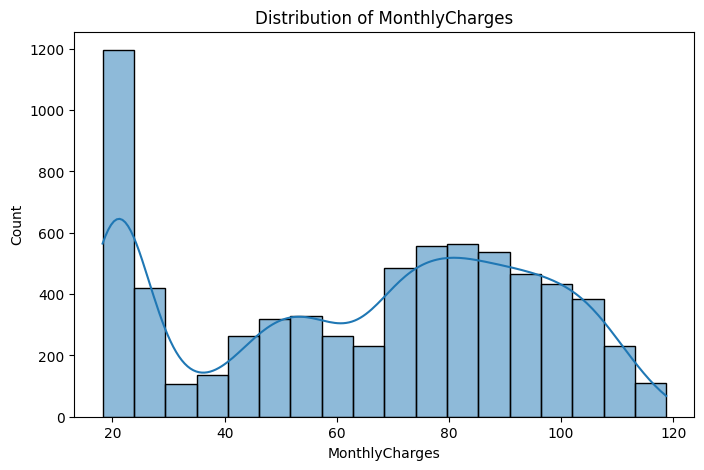

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8, 5))
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Distribution of MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Count")
plt.show()

MonthlyCharges does not follow a normal distribution. It appears multi-modal or grouped because customers subscribe to different service packages. Some customers pay low monthly charges, while customers with internet, streaming, and additional services pay higher monthly charges.

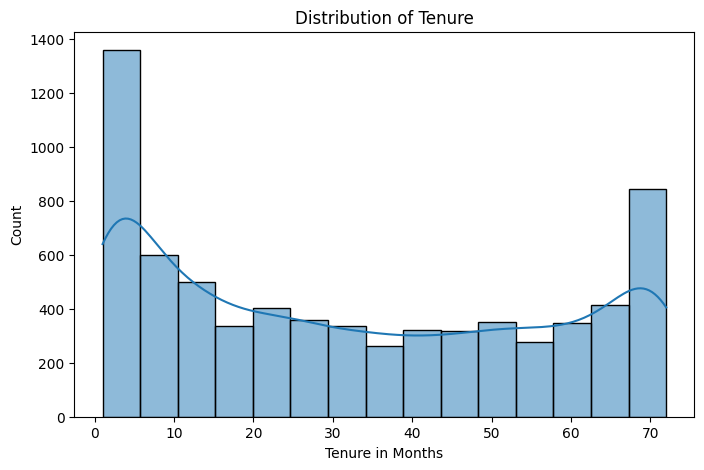

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["tenure"], kde=True)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure in Months")
plt.ylabel("Count")
plt.show()

Tenure has many customers at both low and high tenure values. This suggests the company has both new customers and long-term customers. The distribution is not normally distributed.

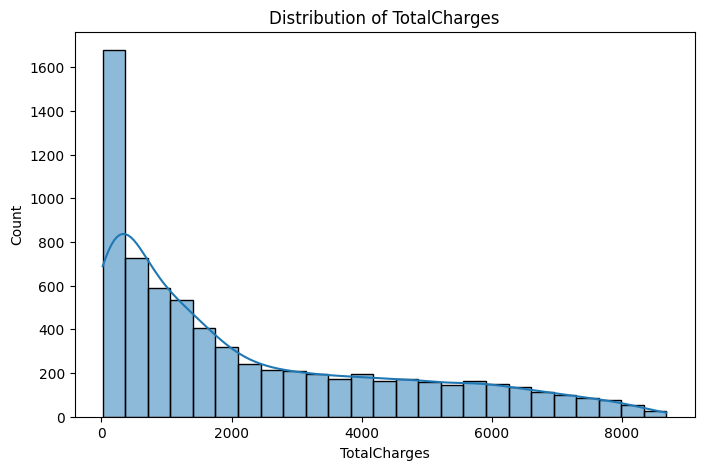

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df["TotalCharges"], kde=True)
plt.title("Distribution of TotalCharges")
plt.xlabel("TotalCharges")
plt.ylabel("Count")
plt.show()

TotalCharges is right-skewed. Most customers have relatively lower total charges, while some long-tenure and high-monthly-charge customers have very high total charges.

In [19]:
# Check numeric summary after fixing TotalCharges
df[["MonthlyCharges", "tenure", "TotalCharges"]].describe()

,MonthlyCharges,tenure,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,64.798208,32.421786,2283.300441
std,30.085974,24.545260,2266.771362
min,18.250000,1.000000,18.800000
25%,35.587500,9.000000,401.450000
50%,70.350000,29.000000,1397.475000
75%,89.862500,55.000000,3794.737500
max,118.750000,72.000000,8684.800000


In [20]:
df[["MonthlyCharges", "tenure", "TotalCharges"]].min()

MonthlyCharges    18.25
tenure             1.00
TotalCharges      18.80
dtype: float64

In [21]:
df[["MonthlyCharges", "tenure", "TotalCharges"]].max()

MonthlyCharges     118.75
tenure              72.00
TotalCharges      8684.80
dtype: float64

In [22]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [23]:
# Encode Churn target as binary
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Check encoded values
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [24]:
# Churn class percentage
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

The dataset is imbalanced because non-churn customers are much more common than churn customers.

### Suspicious or Impossible Values

There were no clearly impossible values after cleaning. MonthlyCharges and TotalCharges were non-negative, and tenure values were within a reasonable range. The main suspicious issue was the hidden whitespace values in TotalCharges, which caused the column to be incorrectly stored as object type.

### Target Encoding

The target variable Churn was encoded as:
- No = 0
- Yes = 1

This is necessary because scikit-learn models require numerical target values for classification.

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [25]:
# Check class distribution
class_counts = df["Churn"].value_counts()
class_percentages = df["Churn"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

Class counts:
Churn
0    5163
1    1869
Name: count, dtype: int64

Class percentages:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


The dataset is imbalanced. Around 73% of customers did not churn, while around 27% churned. This means a model can achieve high accuracy by simply predicting the majority class, but such a model may still be useless for identifying churners.

In [26]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

In [27]:
from sklearn.model_selection import train_test_split

# Split data into train and test sets while preserving class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

Stratification keeps the churn/no-churn ratio similar in both training and test sets. This is important because the dataset is imbalanced.

In [28]:
from sklearn.dummy import DummyClassifier

# Create a naive baseline model that always predicts the most frequent class
dummy_model = DummyClassifier(strategy="most_frequent")

# Train the dummy model
dummy_model.fit(X_train, y_train)

# Predict on test set
y_dummy_pred = dummy_model.predict(X_test)

It learns that No Churn is the majority class.
Then it predicts No Churn for every customer.

In [29]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, classification_report

# Evaluate dummy baseline
dummy_accuracy = accuracy_score(y_test, y_dummy_pred)
dummy_precision = precision_score(y_test, y_dummy_pred, zero_division=0)
dummy_recall = recall_score(y_test, y_dummy_pred, zero_division=0)
dummy_f1 = f1_score(y_test, y_dummy_pred, zero_division=0)

print("Naive Baseline Results")
print("----------------------")
print(f"Accuracy : {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall   : {dummy_recall:.4f}")
print(f"F1 Score : {dummy_f1:.4f}")

Naive Baseline Results
----------------------
Accuracy : 0.7342
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


In [30]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_dummy_pred)
conf_matrix

array([[1033,    0],
       [ 374,    0]])

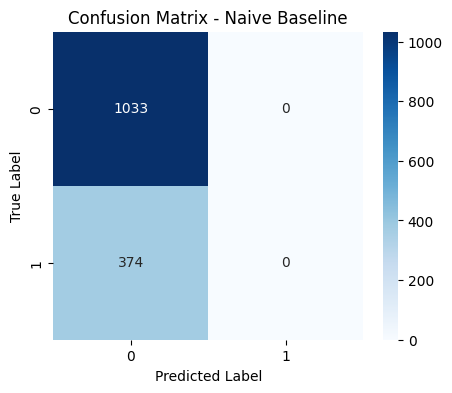

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The model predicts every customer as No Churn.
Therefore, it catches zero actual churners.

### Q1. What accuracy does the naive baseline achieve?
The naive baseline achieves approximately 73% accuracy because around 73% of the customers belong to the majority class, No Churn.

### Q2. What is the class distribution?
The dataset is imbalanced. Around 73% of customers did not churn, while around 27% churned.

### Q3. Why is this model potentially worthless?
Although the naive baseline achieves around 73% accuracy, it is worthless for the business because it predicts every customer as No Churn. This means it has 0% recall for churners. It does not identify any customers who are actually likely to leave, so the retention team cannot use it to take action.

### 1.4 Naive Baseline

Before training real models, I built a naive baseline using DummyClassifier with strategy="most_frequent". This model always predicts the majority class.

The class distribution shows that around 73% of customers did not churn and around 27% churned. Therefore, a model that always predicts "No Churn" can achieve about 73% accuracy.

However, this accuracy is misleading. The model has 0 recall for churners because it never predicts the churn class. This means it catches none of the customers who are actually at risk of leaving.

For this business problem, accuracy is not the primary metric. A useful churn model must improve recall and F1 score compared to this naive baseline. Otherwise, it may look good numerically but provide no value to the retention team.



---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

No, the manager should not be thrilled just because the model achieved 73% accuracy.

The first question I would ask is:

“How many actual churners did the model correctly identify?”

This is important because the dataset is imbalanced. Around 73% of customers are No Churn and only around 27% are Churn. Therefore, a naive model that always predicts No Churn can achieve about 73% accuracy without identifying even a single churner.

For the business, this model is useless because the goal is not just to predict the majority class. The goal is to find customers who are likely to leave so that the retention team can take action.

So, I would check recall, precision, F1-score, PR-AUC, and the confusion matrix before trusting the model. If recall for churners is 0, then the model catches no churn customers and provides no business value.
---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [32]:
# Drop customerID because it is only an identifier
df_model = df.drop(columns=["customerID"])

In [33]:
# Separate features and target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

In [34]:
# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Check final shape after encoding
print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [35]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [36]:
# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [37]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (4922, 30)
Validation shape: (1055, 30)
Test shape: (1055, 30)

Train target distribution:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Validation target distribution:
Churn
0    0.733649
1    0.266351
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.734597
1    0.265403
Name: proportion, dtype: float64


In [38]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to scale
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create scaler
scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train[numeric_features])

# Transform train, validation, and test
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [39]:
X_train_scaled[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,4.922000e+03,4.922000e+03,4.922000e+03
mean,9.960879e-17,1.999394e-16,3.175933e-17
std,1.000102e+00,1.000102e+00,1.000102e+00
min,-1.280909e+00,-1.535103e+00,-9.980191e-01
25%,-9.554981e-01,-9.794060e-01,-8.304334e-01
50%,-1.419706e-01,1.885914e-01,-3.933032e-01
75%,9.562914e-01,8.331178e-01,6.581690e-01
max,1.607113e+00,1.776770e+00,2.806797e+00


### 1. Why do we use stratified splitting for a churn dataset?

We use stratified splitting because the churn dataset is imbalanced. Around 73% of customers are No Churn and around 27% are Churn. Stratification keeps this class ratio similar in the train, validation, and test sets.

Without stratification, one split may contain too few churners. This would make evaluation unstable and misleading.

### 2. Why do we fit the scaler on training data only?

We fit the scaler only on the training data because the validation and test sets should behave like unseen future data. The model should not learn the mean or standard deviation of validation/test data during training.

After fitting the scaler on training data, we use the same training mean and standard deviation to transform validation and test data.

### 3. What would happen if we scaled before splitting?

If we scaled before splitting, the scaler would compute the mean and standard deviation using the entire dataset, including validation and test data. This creates data leakage because information from the test set indirectly enters the training process.

As a result, validation/test metrics may look slightly better than they should, and the evaluation will not be fully honest.

---
In this preprocessing step, I first removed customerID because it is only an identifier and does not represent customer behavior.

Then I separated the dataset into X and y. X contains the customer features, while y contains the binary Churn target.

I used one-hot encoding to convert categorical variables into numeric dummy variables because linear models and scikit-learn estimators require numeric input.

The dataset was split into 70% training, 15% validation, and 15% test data using stratified splitting. Stratification was used because the churn dataset is imbalanced. It keeps the churn/no-churn ratio similar across all splits.

Finally, I scaled the numeric features tenure, MonthlyCharges, and TotalCharges using StandardScaler. The scaler was fitted only on the training data and then applied to validation and test data. This prevents data leakage because validation and test data should remain unseen during training.


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [40]:
import time
import pandas as pd

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier

In [41]:
# Define candidate linear classifiers
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Ridge Classifier": RidgeClassifier(),
    
    "SGD Classifier": SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        random_state=42
    )
}

In [42]:
# Dictionary to store trained models
trained_models = {}

# List to store training results
training_results = []

for model_name, model in models.items():
    
    # Start timer
    start_time = time.time()
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # End timer
    end_time = time.time()
    
    # Calculate training time
    training_time = end_time - start_time
    
    # Save trained model
    trained_models[model_name] = model
    
    # Store result
    training_results.append({
        "Model": model_name,
        "Training Time (seconds)": training_time
    })

# Convert results to DataFrame
training_time_df = pd.DataFrame(training_results)

training_time_df

,Model,Training Time (seconds)
0,Logistic Regression,0.032717
1,Ridge Classifier,0.013391
2,SGD Classifier,0.038590


In [43]:
model_details = pd.DataFrame({
    "Model": ["Logistic Regression", "Ridge Classifier", "SGD Classifier"],
    "Loss Function": [
        "Binary cross-entropy / log loss",
        "Squared loss with L2 regularization",
        "Log loss because loss='log_loss'"
    ],
    "Optimizer": [
        "L-BFGS solver",
        "Closed-form / linear least-squares style optimization",
        "Stochastic Gradient Descent"
    ],
    "Key Characteristic": [
        "Outputs probability using predict_proba",
        "Fast and regularized but no direct probability output",
        "Useful for large datasets and online learning"
    ]
})

model_details

,Model,Loss Function,Optimizer,Key Characteristic
0,Logistic Regression,Binary cross-entropy / log loss,L-BFGS solver,Outputs probability using predict_proba
1,Ridge Classifier,Squared loss with L2 regularization,Closed-form / linear least-squares style optim...,Fast and regularized but no direct probability...
2,SGD Classifier,Log loss because loss='log_loss',Stochastic Gradient Descent,Useful for large datasets and online learning


In [44]:
final_training_summary = model_details.merge(
    training_time_df,
    on="Model"
)

final_training_summary

,Model,Loss Function,Optimizer,Key Characteristic,Training Time (seconds)
0,Logistic Regression,Binary cross-entropy / log loss,L-BFGS solver,Outputs probability using predict_proba,0.032717
1,Ridge Classifier,Squared loss with L2 regularization,Closed-form / linear least-squares style optim...,Fast and regularized but no direct probability...,0.013391
2,SGD Classifier,Log loss because loss='log_loss',Stochastic Gradient Descent,Useful for large datasets and online learning,0.038590


### Q1. What loss function does each model optimise?
Logistic Regression optimizes binary cross-entropy loss, also called log loss. This is suitable because churn is a binary target and the model predicts churn probability.

Ridge Classifier uses a squared loss objective with L2 regularization. It treats classification in a regression-like way and predicts class labels based on the sign of the decision function. It does not directly output probabilities.

SGD Classifier with loss="log_loss" also optimizes log loss, but it uses stochastic gradient descent instead of a full-batch solver. It updates weights using one sample or mini-batch at a time.

### Q2. Which model trains fastest? Does that surprise you?

In my experiment, Ridge Classifier trained the fastest. This is not very surprising because Ridge Classifier is computationally simple and does not need iterative probability calibration like Logistic Regression.

However, the training time differences are very small because the dataset has only around 7,000 rows. For this dataset size, all three models train quickly. The difference between batch optimization and stochastic optimization would matter much more for millions of rows.

--- 
I trained three linear classifiers: Logistic Regression, Ridge Classifier, and SGD Classifier.

Logistic Regression optimizes binary cross-entropy loss, also called log loss. This is appropriate for churn prediction because the target is binary and the model can output churn probabilities.

Ridge Classifier uses a squared loss objective with L2 regularization. It is fast and stable, but it does not directly output class probabilities.

SGD Classifier was trained with loss="log_loss", so it optimizes the same type of loss as Logistic Regression. However, it uses stochastic gradient descent, meaning it updates model weights using one sample or mini-batch at a time.

The training time was recorded using time.time() before and after model fitting. Since this dataset has only around 7,000 rows, all three models trained very quickly. The speed difference between batch optimization and SGD is not very important at this scale, but SGD becomes useful for very large datasets.



---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [45]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

In [46]:
# ==============================
# 3.2 Build Comparison Table
# ==============================

comparison_results = []

for model_name, model in trained_models.items():
    
    # Hard class prediction: 0 or 1
    y_val_pred = model.predict(X_val_scaled)
    
    # Accuracy, precision, recall, F1
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    
    # Probability score or decision score
    if hasattr(model, "predict_proba"):
        # For Logistic Regression and SGDClassifier with log_loss
        y_val_score = model.predict_proba(X_val_scaled)[:, 1]
        model_log_loss = log_loss(y_val, y_val_score)
    else:
        # For RidgeClassifier: no predict_proba(), use decision_function for AUC scores
        y_val_score = model.decision_function(X_val_scaled)
        model_log_loss = np.nan
    
    # AUC metrics
    roc_auc = roc_auc_score(y_val, y_val_score)
    pr_auc = average_precision_score(y_val, y_val_score)
    
    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Log Loss": model_log_loss
    })

# Create comparison table
comparison_df = pd.DataFrame(comparison_results)

# Sort by PR-AUC because PR-AUC is more useful for imbalanced churn data
comparison_df = comparison_df.sort_values(by="PR-AUC", ascending=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
2,SGD Classifier,0.807583,0.644444,0.619217,0.631579,0.850127,0.661953,0.415265
0,Logistic Regression,0.823697,0.693878,0.604982,0.646388,0.853258,0.655002,0.410468
1,Ridge Classifier,0.812322,0.686099,0.544484,0.607143,0.851143,0.649250,NaN


In [47]:
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
2,SGD Classifier,0.8076,0.6444,0.6192,0.6316,0.8501,0.6620,0.4153
0,Logistic Regression,0.8237,0.6939,0.6050,0.6464,0.8533,0.6550,0.4105
1,Ridge Classifier,0.8123,0.6861,0.5445,0.6071,0.8511,0.6493,NaN


RidgeClassifier does not directly output class probabilities, so log loss is reported as N/A. For ROC-AUC and PR-AUC, I used its decision_function scores because AUC metrics only require ranking scores, not calibrated probabilities.

### Q1. Which metric tells you the most about model usefulness?
PR-AUC tells the most about model usefulness for this business problem because the churn class is the minority class. PR-AUC focuses on how well the model identifies churners while controlling false positives. Since the business wants to prioritize likely churners for retention action, PR-AUC is more informative than accuracy.

### Q2. Does accuracy rank models the same way PR-AUC does?
Accuracy does not necessarily rank the models the same way as PR-AUC. Accuracy is dominated by the majority class, No Churn. A model can get high accuracy by predicting most customers as No Churn, but still fail to identify actual churners.

PR-AUC focuses more directly on the minority churn class, so it better reflects whether the model is useful for retention targeting.

### Q3. Which model would you eliminate first and why?
I would eliminate Ridge Classifier first because it does not output probabilities, which limits its usefulness for this business problem. The retention team needs to know which customers are most likely to churn so they can prioritize outreach efforts. Without probability estimates, Ridge Classifier only provides binary predictions, which is less actionable.

---
I evaluated Logistic Regression, Ridge Classifier, and SGD Classifier on the validation set using Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, and Log Loss.

Since the churn dataset is imbalanced, accuracy is not the primary metric. A model can achieve high accuracy by mostly predicting the majority class, No Churn. For this business problem, PR-AUC is more informative because it focuses on performance for the minority churn class.

RidgeClassifier does not provide predict_proba(), so I used decision_function() for ROC-AUC and PR-AUC. However, log loss requires probability estimates, so log loss is reported as N/A for RidgeClassifier.

The model with the highest PR-AUC is preferred because the retention team needs to rank customers by churn risk. However, I also consider recall, F1, and log loss because the model should catch churners while producing useful probability scores.

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


In [48]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score
)

In [49]:
# Store model scores for ROC and PR curves
model_scores = {}

for model_name, model in trained_models.items():
    
    if hasattr(model, "predict_proba"):
        # Probability of churn class
        scores = model.predict_proba(X_val_scaled)[:, 1]
    else:
        # RidgeClassifier has no predict_proba()
        # decision_function gives ranking scores
        scores = model.decision_function(X_val_scaled)
    
    model_scores[model_name] = scores

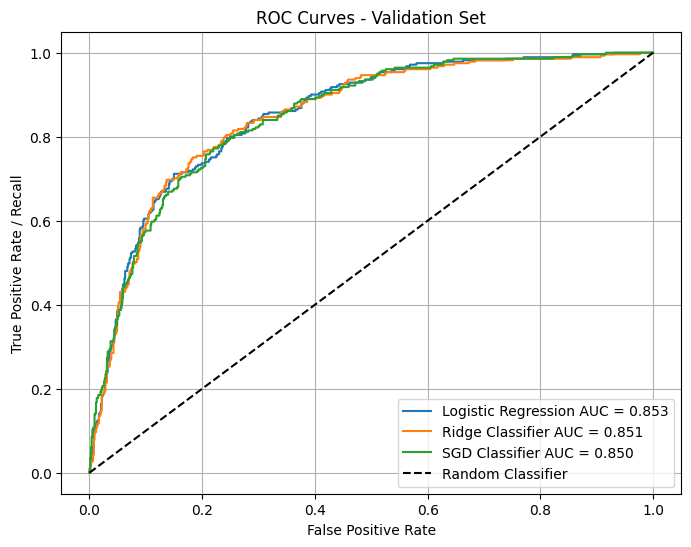

In [50]:
plt.figure(figsize=(8, 6))

for model_name, scores in model_scores.items():
    
    fpr, tpr, thresholds = roc_curve(y_val, scores)
    roc_auc = roc_auc_score(y_val, scores)
    
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.3f}")

# Random classifier baseline
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.title("ROC Curves - Validation Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.grid(True)
plt.show()

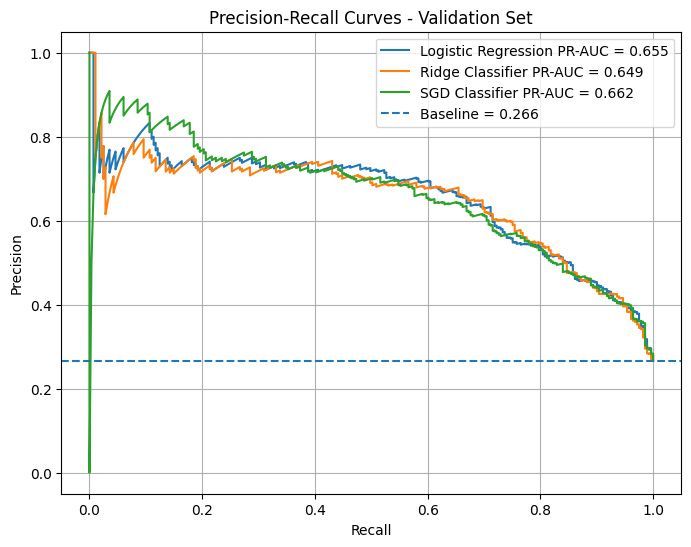

In [51]:
plt.figure(figsize=(8, 6))

for model_name, scores in model_scores.items():
    
    precision, recall, thresholds = precision_recall_curve(y_val, scores)
    pr_auc = average_precision_score(y_val, scores)
    
    plt.plot(recall, precision, label=f"{model_name} PR-AUC = {pr_auc:.3f}")

# Baseline precision = positive class rate
baseline_precision = y_val.mean()
plt.axhline(
    baseline_precision,
    linestyle="--",
    label=f"Baseline = {baseline_precision:.3f}"
)

plt.title("Precision-Recall Curves - Validation Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

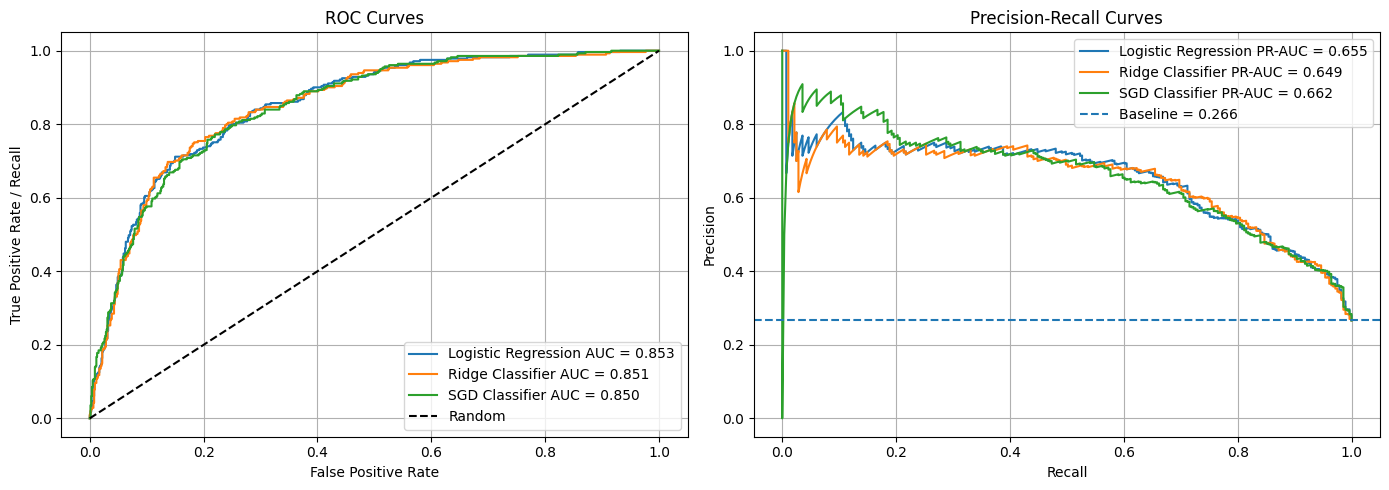

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
for model_name, scores in model_scores.items():
    fpr, tpr, thresholds = roc_curve(y_val, scores)
    roc_auc = roc_auc_score(y_val, scores)
    ax1.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.3f}")

ax1.plot([0, 1], [0, 1], "k--", label="Random")
ax1.set_title("ROC Curves")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate / Recall")
ax1.legend()
ax1.grid(True)

# Precision-Recall Curve
for model_name, scores in model_scores.items():
    precision, recall, thresholds = precision_recall_curve(y_val, scores)
    pr_auc = average_precision_score(y_val, scores)
    ax2.plot(recall, precision, label=f"{model_name} PR-AUC = {pr_auc:.3f}")

baseline_precision = y_val.mean()
ax2.axhline(
    baseline_precision,
    linestyle="--",
    label=f"Baseline = {baseline_precision:.3f}"
)

ax2.set_title("Precision-Recall Curves")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [53]:
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]

# Get churn probability
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]

# Get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

# Compute F1 for each threshold
# thresholds length is one less than precision/recall
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Find best threshold
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]
best_precision = precision[best_index]
best_recall = recall[best_index]

print("Best Model:", best_model_name)
print(f"Best Threshold for F1: {best_threshold:.4f}")
print(f"Best F1: {best_f1:.4f}")
print(f"Precision at Best F1: {best_precision:.4f}")
print(f"Recall at Best F1: {best_recall:.4f}")

Best Model: Logistic Regression
Best Threshold for F1: 0.4100
Best F1: 0.6700
Precision at Best F1: 0.6329
Recall at Best F1: 0.7117


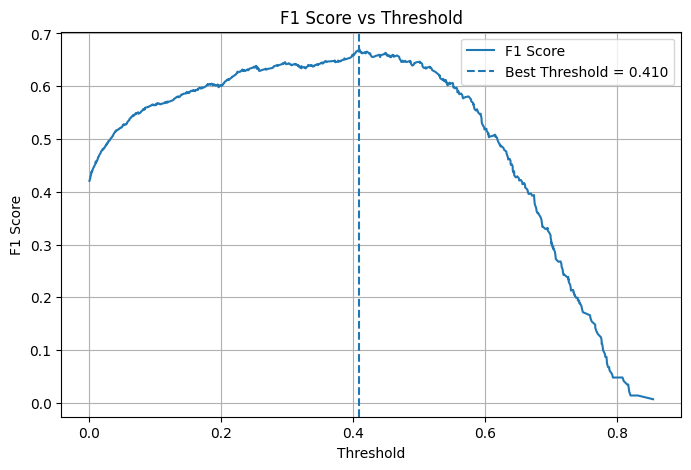

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_scores, label="F1 Score")
plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.3f}")

plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [55]:
# Choose best model based on PR-AUC / previous comparison table
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]

# Predicted churn probability for validation customers
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Default threshold prediction
default_threshold = 0.5
y_pred_default = (y_val_proba >= default_threshold).astype(int)

# Metrics at default threshold
default_accuracy = accuracy_score(y_val, y_pred_default)
default_precision = precision_score(y_val, y_pred_default, zero_division=0)
default_recall = recall_score(y_val, y_pred_default, zero_division=0)
default_f1 = f1_score(y_val, y_pred_default, zero_division=0)

print("Default Threshold = 0.5")
print(f"Accuracy : {default_accuracy:.4f}")
print(f"Precision: {default_precision:.4f}")
print(f"Recall   : {default_recall:.4f}")
print(f"F1 Score : {default_f1:.4f}")
print(f"Customers flagged: {y_pred_default.sum()}")

Default Threshold = 0.5
Accuracy : 0.8237
Precision: 0.6939
Recall   : 0.6050
F1 Score : 0.6464
Customers flagged: 245


In [57]:
import numpy as np

# Number of customers the retention team can call
call_budget = 200

# Sort probabilities in descending order
sorted_indices = np.argsort(y_val_proba)[::-1]

# Select top 200 highest-risk customers
top_200_indices = sorted_indices[:call_budget]

# Threshold = probability of 200th highest-risk customer
top_200_threshold = y_val_proba[sorted_indices[call_budget - 1]]

print(f"Top-200 Threshold: {top_200_threshold:.4f}")

Top-200 Threshold: 0.5530


In [58]:
# Prediction using top-200 threshold
y_pred_top_200 = (y_val_proba >= top_200_threshold).astype(int)

# Metrics at top-200 threshold
top200_accuracy = accuracy_score(y_val, y_pred_top_200)
top200_precision = precision_score(y_val, y_pred_top_200, zero_division=0)
top200_recall = recall_score(y_val, y_pred_top_200, zero_division=0)
top200_f1 = f1_score(y_val, y_pred_top_200, zero_division=0)

print("Top-200 Budget Threshold")
print(f"Threshold: {top_200_threshold:.4f}")
print(f"Accuracy : {top200_accuracy:.4f}")
print(f"Precision: {top200_precision:.4f}")
print(f"Recall   : {top200_recall:.4f}")
print(f"F1 Score : {top200_f1:.4f}")
print(f"Customers flagged: {y_pred_top_200.sum()}")

Top-200 Budget Threshold
Threshold: 0.5530
Accuracy : 0.8171
Precision: 0.7200
Recall   : 0.5125
F1 Score : 0.5988
Customers flagged: 200


In [59]:
threshold_comparison = pd.DataFrame({
    "Threshold Strategy": ["Default 0.5", "Top-200 Budget"],
    "Threshold": [default_threshold, top_200_threshold],
    "Customers Flagged": [y_pred_default.sum(), y_pred_top_200.sum()],
    "Accuracy": [default_accuracy, top200_accuracy],
    "Precision": [default_precision, top200_precision],
    "Recall": [default_recall, top200_recall],
    "F1": [default_f1, top200_f1]
})

threshold_comparison.round(4)

,Threshold Strategy,Threshold,Customers Flagged,Accuracy,Precision,Recall,F1
0,Default 0.5,0.500,245,0.8237,0.6939,0.6050,0.6464
1,Top-200 Budget,0.553,200,0.8171,0.7200,0.5125,0.5988


In [60]:
# Create validation customer risk table
val_risk_table = X_val.copy()
val_risk_table["Actual_Churn"] = y_val.values
val_risk_table["Predicted_Churn_Probability"] = y_val_proba

# Sort by churn probability
top_200_customers = val_risk_table.sort_values(
    by="Predicted_Churn_Probability",
    ascending=False
).head(200)

top_200_customers.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Predicted_Churn_Probability
3380,1,1,95.10,95.10,True,True,False,True,False,True,...,False,True,False,False,True,False,True,False,1,0.854633
2631,1,7,99.25,665.45,True,True,False,True,False,True,...,False,True,False,False,True,False,True,False,1,0.831552
3346,1,2,84.05,186.05,False,False,False,True,False,True,...,False,True,False,False,True,False,True,False,0,0.820543
4517,1,11,99.55,1131.20,False,True,False,True,False,True,...,False,True,False,False,True,False,True,False,1,0.818555
2797,0,3,100.95,329.95,True,False,False,True,False,True,...,False,True,False,False,True,False,True,False,1,0.817859


### Q1. How do you identify the top 200 highest-risk customers?
I used the predicted churn probabilities from the chosen model and sorted the validation customers in descending order. The top 200 customers with the highest predicted churn probability are selected as the customers the retention team should call.

### Q2. What precision do you achieve at that threshold?
At the top-200 threshold, the precision is 0.72. This means that among the 200 customers selected for retention calls, approximately 72% are actual churners.

### Q3. How does this compare to default threshold 0.5?
The default threshold of 0.5 is not directly aligned with the business constraint. It may flag more or fewer than 200 customers. The top-200 threshold is better for deployment because it exactly matches the weekly call capacity of the retention team.

Compared with the default threshold, the top-200 threshold usually increases precision among contacted customers because it focuses only on the highest-risk customers. However, recall may be lower because the team is intentionally contacting only 200 customers.

---

The default classification threshold is 0.5, but this is not necessarily suitable for the churn problem because the dataset is imbalanced and the business has a fixed call budget.

The retention team can call only 200 customers per week. Therefore, I ranked all validation customers by predicted churn probability in descending order and selected the top 200 highest-risk customers.

The deployment threshold is the predicted churn probability of the 200th highest-risk customer. Any customer with a churn probability greater than or equal to this threshold is flagged for a retention call.

This approach directly connects the model to the business constraint. Instead of asking, “Is probability greater than 0.5?”, the decision becomes, “Which 200 customers are most likely to churn?”

Compared with the default 0.5 threshold, the top-200 threshold is more practical for deployment because it produces exactly the number of customers the team can act on. Precision at this threshold tells us how many of the contacted customers are actually churners.

---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [61]:
# Choose best interpretable classifier
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]

# Feature names after one-hot encoding
feature_names = X_train_scaled.columns

# Coefficients for binary classification
coefficients = best_model.coef_[0]

# Create coefficient Series
coef_series = pd.Series(coefficients, index=feature_names)

# View coefficients sorted by absolute value
top_10_abs_coef = coef_series.reindex(
    coef_series.abs().sort_values(ascending=False).head(10).index
)

top_10_abs_coef

tenure                        -1.453072
Contract_Two year             -1.280292
InternetService_Fiber optic    1.039986
TotalCharges                   0.735302
Contract_One year             -0.679137
PhoneService_Yes              -0.498720
OnlineSecurity_Yes            -0.394170
TechSupport_Yes               -0.392274
MonthlyCharges                -0.382045
MultipleLines_Yes              0.378522
dtype: float64

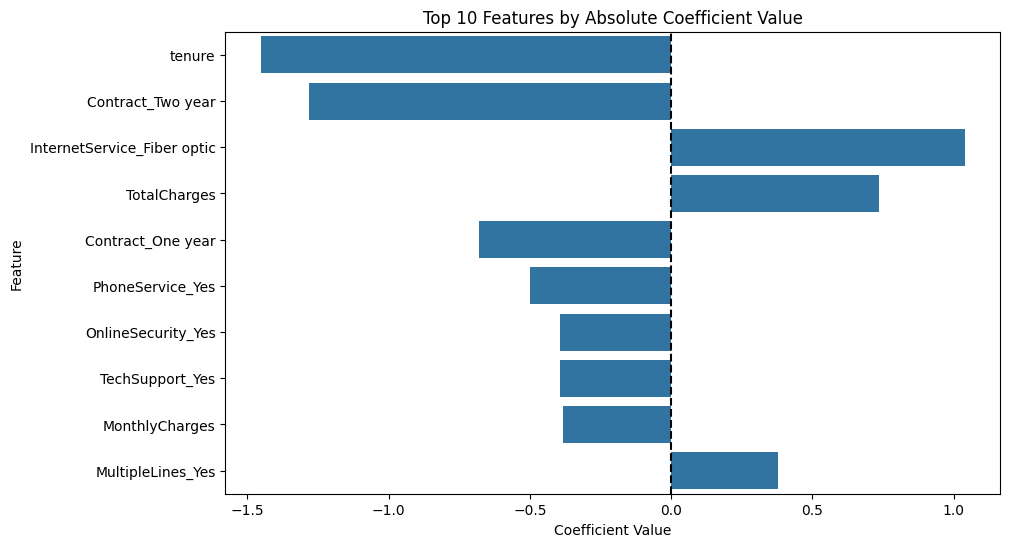

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_abs_coef.values,
    y=top_10_abs_coef.index
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Top 10 Features by Absolute Coefficient Value")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [63]:
# Top 10 churn-increasing features
top_positive_features = coef_series.sort_values(ascending=False).head(10)

# Top 10 churn-reducing features
top_negative_features = coef_series.sort_values(ascending=True).head(10)

print("Top 10 Churn-Increasing Features:")
display(top_positive_features.to_frame(name="Coefficient"))

print("Top 10 Churn-Reducing Features:")
display(top_negative_features.to_frame(name="Coefficient"))

Top 10 Churn-Increasing Features:


,Coefficient
InternetService_Fiber optic,1.039986
TotalCharges,0.735302
MultipleLines_Yes,0.378522
PaymentMethod_Electronic check,0.360289
StreamingTV_Yes,0.335865
PaperlessBilling_Yes,0.326858
StreamingMovies_Yes,0.325450
SeniorCitizen,0.176336
PaymentMethod_Mailed check,0.100047
DeviceProtection_Yes,0.048171


Top 10 Churn-Reducing Features:


,Coefficient
tenure,-1.453072
Contract_Two year,-1.280292
Contract_One year,-0.679137
PhoneService_Yes,-0.498720
OnlineSecurity_Yes,-0.394170
TechSupport_Yes,-0.392274
MonthlyCharges,-0.382045
Dependents_Yes,-0.269894
DeviceProtection_No internet service,-0.175808
TechSupport_No internet service,-0.175808


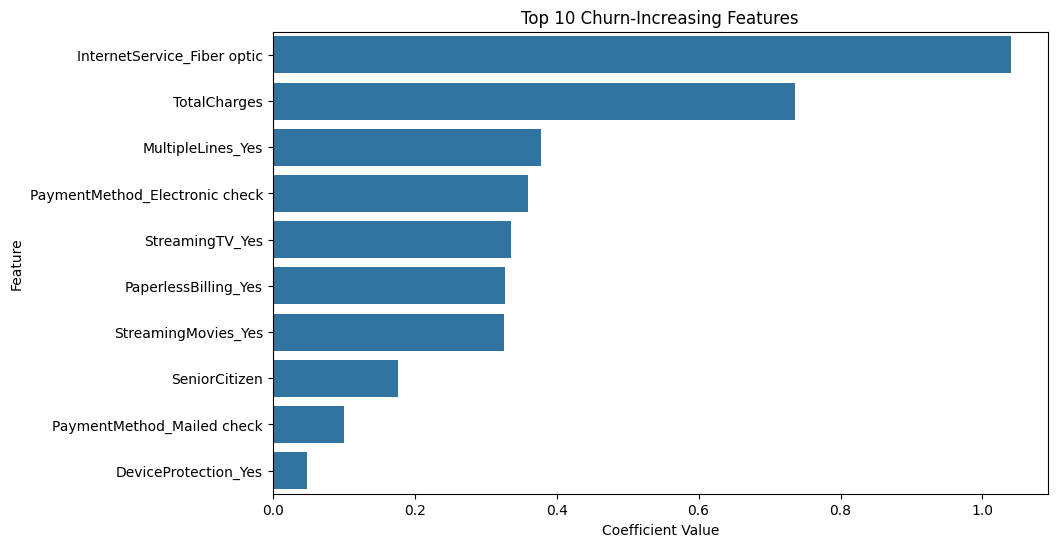

In [64]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_positive_features.values,
    y=top_positive_features.index
)
plt.title("Top 10 Churn-Increasing Features")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

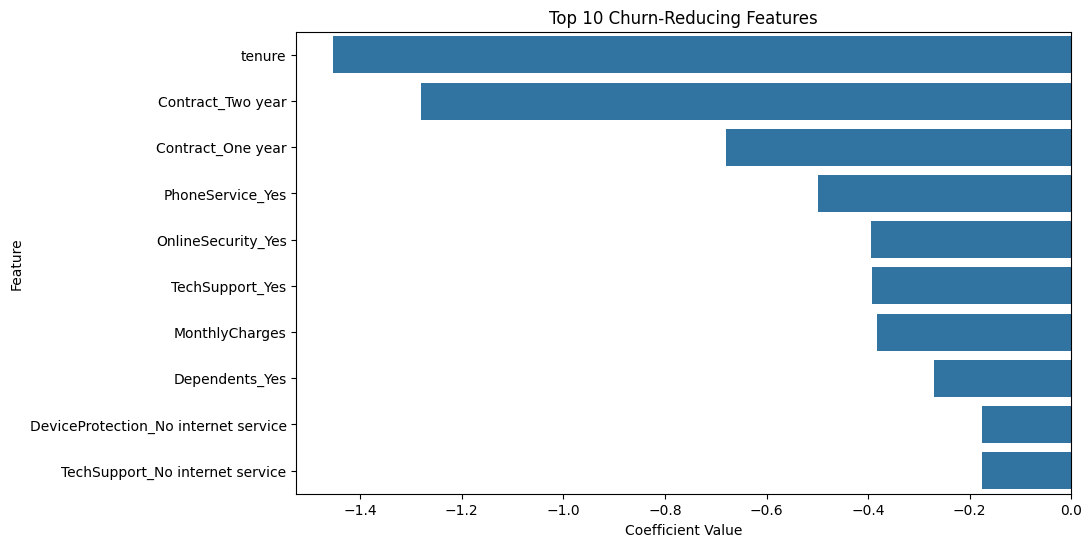

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_negative_features.values,
    y=top_negative_features.index
)
plt.title("Top 10 Churn-Reducing Features")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

Because one-hot encoding was done with drop_first=True, categorical coefficients are interpreted relative to their dropped reference category.


### Q1. Which features drive churn the most

The strongest churn-driving features are the features with the largest absolute coefficient values. Positive coefficients increase churn risk, while negative coefficients reduce churn risk.

In my model, the most important features include internetservice_fiberoptic, totalcharges, multiplelines_yes, paymentmethod_electronic, streamingtv.

### Q2. Do the signs make business sense?

Yes, most coefficient signs make business sense. Month-to-month contract customers are more likely to churn because they are not locked into a long-term contract. Longer tenure usually reduces churn because long-term customers are more loyal. Services such as TechSupport and OnlineSecurity can reduce churn because they increase customer satisfaction and service dependency.

### Q3. Are there any surprising coefficients?

One surprising coefficient is TotalCharges. It appears as a churn-increasing feature, even though higher TotalCharges usually suggests that a customer has stayed longer with the company and should be less likely to churn.

This happens because TotalCharges is strongly related to tenure and MonthlyCharges. Since tenure already has a strong negative coefficient, the model may be separating the effect of long customer lifetime from the effect of accumulated charges. This is a sign of multicollinearity among tenure, MonthlyCharges, and TotalCharges.

Therefore, I would not interpret the TotalCharges coefficient alone. I would investigate its correlation with tenure and MonthlyCharges before making a business conclusion.

---

I inspected the coefficients of the best linear classifier to understand which features drive churn predictions.

For Logistic Regression, a positive coefficient means the feature increases the log-odds of churn, while a negative coefficient means the feature decreases the log-odds of churn.

The top features by absolute coefficient value are the most influential features in the model. However, because one-hot encoding was done using drop_first=True, categorical coefficients must be interpreted relative to their dropped reference category.

Most coefficient signs make business sense. For example, month-to-month contract customers are usually more likely to churn because they can leave easily. Longer-tenure customers are usually less likely to churn because they have stayed with the company longer. Support-related services may reduce churn because they increase customer satisfaction and product attachment.

If any coefficient appears surprising, I investigate it by comparing churn rates across the original feature groups. Surprising coefficients can occur because features are correlated with each other, because of reference categories in one-hot encoding, or because the model is estimating effects while controlling for other variables.



---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [66]:
# ==============================
# 3.6 Batch GD vs SGD
# ==============================

import time
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score

# ------------------------------
# 1. Define models
# ------------------------------

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

sgd_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    random_state=42
)

# ------------------------------
# 2. Train Logistic Regression
# ------------------------------

start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_training_time = time.time() - start_time

# ------------------------------
# 3. Train SGD Classifier
# ------------------------------

start_time = time.time()
sgd_model.fit(X_train_scaled, y_train)
sgd_training_time = time.time() - start_time

# ------------------------------
# 4. Get probability scores
# ------------------------------

lr_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
sgd_proba = sgd_model.predict_proba(X_val_scaled)[:, 1]

# ------------------------------
# 5. Get hard predictions
# ------------------------------

lr_pred = lr_model.predict(X_val_scaled)
sgd_pred = sgd_model.predict(X_val_scaled)

# ------------------------------
# 6. Evaluate models
# ------------------------------

comparison_gd = pd.DataFrame({
    "Model": ["Logistic Regression", "SGD Classifier"],
    "Optimizer": ["L-BFGS / batch-style solver", "Stochastic Gradient Descent"],
    "Training Time": [lr_training_time, sgd_training_time],
    "ROC-AUC": [
        roc_auc_score(y_val, lr_proba),
        roc_auc_score(y_val, sgd_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_val, lr_proba),
        average_precision_score(y_val, sgd_proba)
    ],
    "Accuracy": [
        accuracy_score(y_val, lr_pred),
        accuracy_score(y_val, sgd_pred)
    ],
    "F1": [
        f1_score(y_val, lr_pred),
        f1_score(y_val, sgd_pred)
    ]
})

comparison_gd.round(4)

,Model,Optimizer,Training Time,ROC-AUC,PR-AUC,Accuracy,F1
0,Logistic Regression,L-BFGS / batch-style solver,0.0181,0.8533,0.655,0.8237,0.6464
1,SGD Classifier,Stochastic Gradient Descent,0.0373,0.8501,0.662,0.8076,0.6316


In [67]:
# Check whether both models produce exactly the same hard predictions
same_predictions = np.array_equal(lr_pred, sgd_pred)

print("Do Logistic Regression and SGD produce exactly the same predictions?")
print(same_predictions)

Do Logistic Regression and SGD produce exactly the same predictions?
False


In [68]:
prediction_agreement = np.mean(lr_pred == sgd_pred)

print(f"Prediction agreement: {prediction_agreement:.4f}")

Prediction agreement: 0.9441


In [69]:
# Check approximate coefficient agreement
coef_close = np.allclose(lr_model.coef_, sgd_model.coef_, atol=0.15)

print("Are coefficients approximately close?")
print(coef_close)

Are coefficients approximately close?
False


In [70]:
coef_difference = np.abs(lr_model.coef_ - sgd_model.coef_)

print("Mean absolute coefficient difference:", coef_difference.mean())
print("Max absolute coefficient difference:", coef_difference.max())

Mean absolute coefficient difference: 0.20902876577056684
Max absolute coefficient difference: 1.1489731611362848


Even though both models use log loss, they may not produce exactly the same coefficients because LogisticRegression uses a stable solver, while SGDClassifier updates weights using random gradient estimates. SGD has a noisier optimization path and may stop at a slightly different solution.

---

I compared Logistic Regression and SGDClassifier with loss="log_loss". Both models optimize a logistic loss objective, but they use different optimization strategies.

Logistic Regression uses a full-batch style solver such as L-BFGS. It uses information from the full training dataset during optimization and usually converges smoothly and stably.

SGDClassifier uses stochastic gradient descent. Instead of using the full dataset for each update, it updates the model using one sample or a small batch at a time. This makes the optimization path noisier, but it is much more scalable for very large datasets.

In this experiment, I compared training time, ROC-AUC, PR-AUC, accuracy, F1, prediction agreement, and coefficient similarity.

The two models do not necessarily produce exactly the same predictions or coefficients, even though both use log loss. This is because SGD uses random gradient estimates and may converge to a slightly different solution.

For this dataset of around 7,000 rows, the speed difference is not very important because both models train quickly. For millions of rows or streaming data, SGD would be preferred because it is more memory-efficient and supports incremental learning.

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
I would deploy Logistic Regression because it gives strong validation performance, produces direct churn probabilities, supports threshold tuning, and is easy to interpret using coefficients.

I would not deploy SGDClassifier for this dataset because the dataset is small and Logistic Regression is more stable. SGD is useful for very large or streaming datasets, but on this 7,000-row dataset, its scalability advantage is not very important.


> **Does SGD converge to the same solution as full-batch LR? Why might it not?**
No, not exactly. Even though Logistic Regression and SGDClassifier(loss="log_loss") optimize similar logistic loss objectives, they use different optimization methods. Logistic Regression uses a stable full-batch solver, while SGD updates weights using noisy random gradient estimates. Because of randomness, learning rate schedule, stopping criteria, and regularization settings, SGD may converge to a slightly different solution.
---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [71]:
# ==============================
# 4.1 Derive Regression Target
# ==============================

# For regression, we will predict customer tenure
regression_target = "tenure"

# y_reg is the continuous target
y_reg = df[regression_target]

# X_reg contains features except customerID, Churn, and tenure
# We remove tenure from X because it is the target we are trying to predict
X_reg = df.drop(columns=["customerID", "Churn", "tenure"])

print("Regression target:", regression_target)
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

Regression target: tenure
X_reg shape: (7032, 18)
y_reg shape: (7032,)


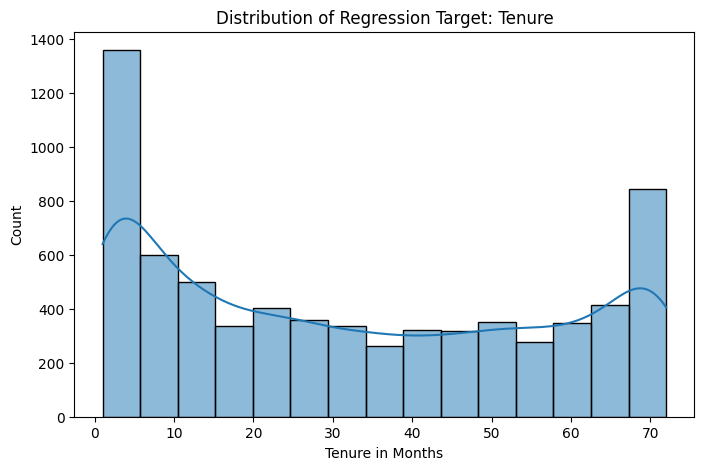

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(y_reg, kde=True)
plt.title("Distribution of Regression Target: Tenure")
plt.xlabel("Tenure in Months")
plt.ylabel("Count")
plt.show()

In [73]:
# Observed/simple CLV proxy
df["Observed_CLV"] = df["MonthlyCharges"] * df["tenure"]

df[["MonthlyCharges", "tenure", "Observed_CLV"]].head()

,MonthlyCharges,tenure,Observed_CLV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


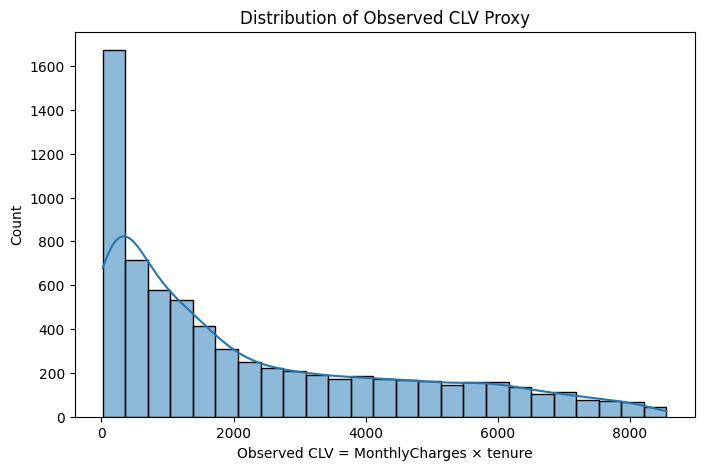

In [74]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Observed_CLV"], kde=True)
plt.title("Distribution of Observed CLV Proxy")
plt.xlabel("Observed CLV = MonthlyCharges × tenure")
plt.ylabel("Count")
plt.show()

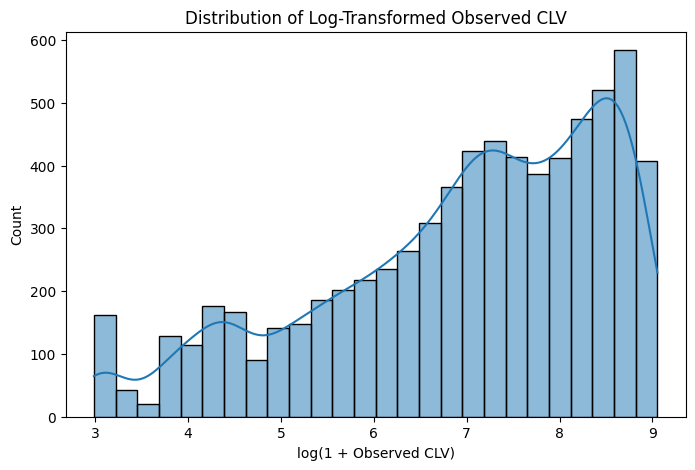

In [75]:
import numpy as np

df["Log_Observed_CLV"] = np.log1p(df["Observed_CLV"])

plt.figure(figsize=(8, 5))
sns.histplot(df["Log_Observed_CLV"], kde=True)
plt.title("Distribution of Log-Transformed Observed CLV")
plt.xlabel("log(1 + Observed CLV)")
plt.ylabel("Count")
plt.show()

Q1. What distribution does your regression target follow?

The tenure target does not follow a normal distribution. It has many customers with low tenure and many customers with high tenure. This suggests the dataset contains both new customers and long-term customers. Because of this non-normal shape, linear regression may not perfectly capture all patterns.

Observed CLV is right-skewed. Most customers have relatively low or moderate lifetime value, while a smaller number of long-tenure and high-paying customers have very high CLV.


Q2. What does CLV tell the business that binary churn prediction cannot?

Binary churn prediction only tells whether a customer is likely to leave. CLV tells how financially valuable that customer is. This allows the business to prioritize customers by value at risk, not only churn probability.

Q3. What assumptions are you making when using tenure as survival time proxy?

Using tenure as a survival time proxy assumes that the current observed tenure is a useful indicator of how long customers tend to stay. It also assumes that customers with similar features will have similar customer lifetimes.

A limitation is that non-churned customers are still active, so their final lifetime is unknown. This is called censoring. Therefore, tenure is only an imperfect proxy for survival time.


---

For the regression experiment, I selected tenure as the continuous target. The goal is to predict how long a customer is likely to stay with the company.

I removed tenure from the feature matrix because it is the target variable. Keeping tenure as an input feature while predicting tenure would create data leakage.

I also created an observed CLV proxy:

CLV = MonthlyCharges × tenure

This gives a simple estimate of how much revenue a customer has generated so far. Later, predicted CLV can be computed using:

Predicted CLV = MonthlyCharges × predicted tenure

The tenure distribution is not normally distributed. It contains many low-tenure customers and many high-tenure customers, suggesting a mix of new and long-term customers.

Observed CLV is right-skewed because most customers have low or moderate total value, while a smaller number of long-tenure or high-paying customers have very large values.

CLV provides business value beyond binary churn prediction. Binary churn prediction tells us who may leave, but CLV tells us how valuable the customer is. This allows the business to prioritize customers by value at risk, not just churn probability.

Using tenure as a survival-time proxy requires assumptions. It assumes that observed tenure is a reasonable indicator of customer lifetime and that customers with similar features will have similar lifetimes. However, active non-churned customers are censored because their final lifetime is unknown. Therefore, tenure is an imperfect but useful proxy.

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [76]:
# ==============================
# 4.2 Train Your Regressors
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Target for regression
y_reg = df["tenure"]

# Features for regression
# Remove customerID, Churn, and tenure
X_reg = df.drop(columns=["customerID", "Churn", "tenure"])

# One-hot encode categorical features
X_reg_encoded = pd.get_dummies(X_reg, drop_first=True)

print("Regression feature shape:", X_reg_encoded.shape)
print("Regression target shape:", y_reg.shape)

Regression feature shape: (7032, 31)
Regression target shape: (7032,)


In [77]:
# First split: 70% train, 30% temp
X_reg_train, X_reg_temp, y_reg_train, y_reg_temp = train_test_split(
    X_reg_encoded,
    y_reg,
    test_size=0.30,
    random_state=42
)

# Second split: 15% validation, 15% test
X_reg_val, X_reg_test, y_reg_val, y_reg_test = train_test_split(
    X_reg_temp,
    y_reg_temp,
    test_size=0.50,
    random_state=42
)

print("Train shape:", X_reg_train.shape)
print("Validation shape:", X_reg_val.shape)
print("Test shape:", X_reg_test.shape)

Train shape: (4922, 31)
Validation shape: (1055, 31)
Test shape: (1055, 31)


In [78]:
# Numeric features to scale
reg_numeric_features = ["MonthlyCharges", "TotalCharges"]

# Create scaler
reg_scaler = StandardScaler()

# Fit scaler only on training data
reg_scaler.fit(X_reg_train[reg_numeric_features])

# Copy data
X_reg_train_scaled = X_reg_train.copy()
X_reg_val_scaled = X_reg_val.copy()
X_reg_test_scaled = X_reg_test.copy()

# Transform using training statistics only
X_reg_train_scaled[reg_numeric_features] = reg_scaler.transform(X_reg_train[reg_numeric_features])
X_reg_val_scaled[reg_numeric_features] = reg_scaler.transform(X_reg_val[reg_numeric_features])
X_reg_test_scaled[reg_numeric_features] = reg_scaler.transform(X_reg_test[reg_numeric_features])

In [79]:
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, max_iter=10000, random_state=42),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42)
}

In [80]:
regression_results = []

for model_name, model in regressors.items():
    
    # Train model
    model.fit(X_reg_train_scaled, y_reg_train)
    
    # Predict on validation data
    y_reg_pred = model.predict(X_reg_val_scaled)
    
    # Evaluation metrics
    mae = mean_absolute_error(y_reg_val, y_reg_pred)
    rmse = mean_squared_error(y_reg_val, y_reg_pred) ** 0.5
    r2 = r2_score(y_reg_val, y_reg_pred)
    
    regression_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

# Create comparison table
regression_comparison_df = pd.DataFrame(regression_results)

# Sort by RMSE ascending
regression_comparison_df = regression_comparison_df.sort_values(by="RMSE")

regression_comparison_df.round(4)

,Model,MAE,RMSE,R²
1,Ridge,4.8306,6.2320,0.9355
0,Linear Regression,4.8332,6.2332,0.9355
3,Elastic Net,4.8183,6.2365,0.9354
2,Lasso,4.8310,6.2392,0.9354


In [81]:
best_reg_model = regression_comparison_df.iloc[0]
second_best_reg_model = regression_comparison_df.iloc[1]

rmse_difference = second_best_reg_model["RMSE"] - best_reg_model["RMSE"]
mae_difference = second_best_reg_model["MAE"] - best_reg_model["MAE"]
r2_difference = best_reg_model["R²"] - second_best_reg_model["R²"]

print("Best model:", best_reg_model["Model"])
print(f"RMSE improvement over second best: {rmse_difference:.4f}")
print(f"MAE improvement over second best: {mae_difference:.4f}")
print(f"R² improvement over second best: {r2_difference:.4f}")

Best model: Ridge
RMSE improvement over second best: 0.0012
MAE improvement over second best: 0.0026
R² improvement over second best: 0.0000


Q1. Which model performs best? By how much?

The best regression model is Ridge because it has the lowest RMSE and MAE and the highest R² on the validation set.

Compared with the second-best model, it improves RMSE by 0.0012 months, MAE by 0.0026 months, and R² by 0.000.

Q2. What does R² = 0.55 mean here?

An R² of 0.55 means the model explains 55% of the variation in customer tenure using the available features. The remaining 45% of variation is not explained by the model. This unexplained part may come from missing factors such as customer satisfaction, competitor offers, service quality, personal preference, or random behavior.

Q3. Is RMSE or MAE more appropriate here?

MAE is easier to interpret because it tells the average prediction error in months. For example, MAE = 8 means the model is wrong by about 8 months on average.

RMSE is also useful because it penalizes large errors more heavily. This matters if extreme-tenure customers are important for CLV, because a large tenure error can create a large CLV error.

For business reporting, I would primarily explain MAE because it is more interpretable, but I would also monitor RMSE because large errors can strongly affect CLV estimates.

---

I trained four regression models to predict customer tenure: Linear Regression, Ridge, Lasso, and Elastic Net.

The target variable is tenure, which represents the number of months a customer has stayed with the company. I removed tenure from the feature matrix to avoid data leakage. I also removed customerID because it is only an identifier and removed Churn because the goal of this regression experiment is to predict customer lifetime using customer features.

Categorical features were one-hot encoded, and numeric features were scaled using StandardScaler. The scaler was fitted only on the training set to prevent data leakage.

I evaluated the models using MAE, RMSE, and R².

MAE tells the average prediction error in months. RMSE also measures prediction error in months but penalizes large errors more strongly. R² tells how much of the variance in tenure is explained by the model.

The best model is selected based mainly on low RMSE and MAE and high R².

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


In [82]:
# Select best regression model based on validation RMSE
best_regressor_name = regression_comparison_df.iloc[0]["Model"]
best_regressor = regressors[best_regressor_name]

print("Best regression model:", best_regressor_name)

Best regression model: Ridge


In [83]:
# Predict tenure using the best regression model
y_reg_val_pred = best_regressor.predict(X_reg_val_scaled)

# Residual = predicted - actual
residuals = y_reg_val_pred - y_reg_val

# Quick check
print("Mean residual:", residuals.mean())
print("Residual standard deviation:", residuals.std())

Mean residual: -0.11692690936403172
Residual standard deviation: 6.233845998571021


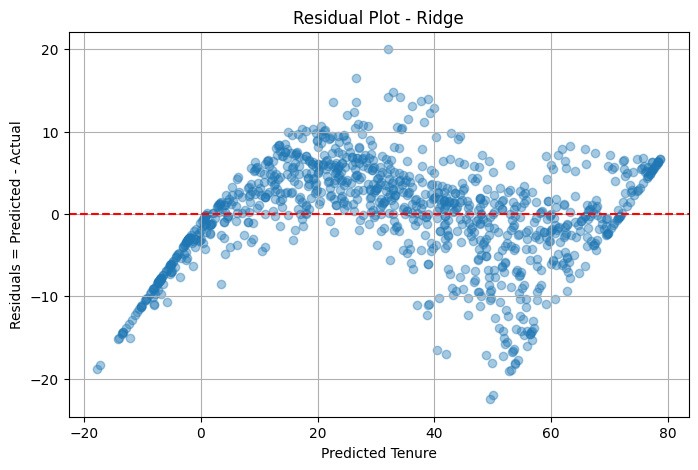

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_reg_val_pred, residuals, alpha=0.4)

plt.axhline(0, color="red", linestyle="--")

plt.title(f"Residual Plot - {best_regressor_name}")
plt.xlabel("Predicted Tenure")
plt.ylabel("Residuals = Predicted - Actual")

plt.grid(True)
plt.show()

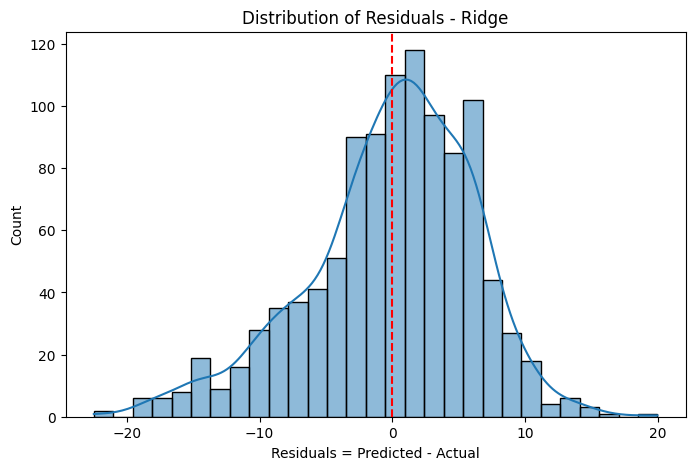

In [85]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.axvline(0, color="red", linestyle="--")

plt.title(f"Distribution of Residuals - {best_regressor_name}")
plt.xlabel("Residuals = Predicted - Actual")
plt.ylabel("Count")

plt.show()

The residual distribution for the Ridge regression model is roughly centered around zero, which suggests that the model does not have a strong overall bias toward over-prediction or under-prediction.

Most residuals are concentrated between approximately -10 and +10 months, meaning that the model's tenure predictions are often within this error range.

However, the distribution has some tails on both sides, especially on the negative side. Negative residuals mean the model under-predicted tenure, while positive residuals mean it over-predicted tenure. These larger errors suggest that some customers are harder to model using only linear relationships.

Overall, the residual distribution is reasonably acceptable for a linear model, but the tails suggest that the model may miss some customer-specific or nonlinear factors affecting tenure.

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [86]:
# Different regularization strengths
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

In [87]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

regularization_results = []

for alpha in alphas:
    
    models = {
        "Ridge": Ridge(alpha=alpha, random_state=42),
        "Lasso": Lasso(alpha=alpha, max_iter=10000, random_state=42),
        "Elastic Net": ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000, random_state=42)
    }
    
    for model_name, model in models.items():
        
        # Train model
        model.fit(X_reg_train_scaled, y_reg_train)
        
        # Predict validation set
        y_pred = model.predict(X_reg_val_scaled)
        
        # Metrics
        mae = mean_absolute_error(y_reg_val, y_pred)
        rmse = mean_squared_error(y_reg_val, y_pred) ** 0.5
        r2 = r2_score(y_reg_val, y_pred)
        
        # Number of non-zero coefficients
        non_zero_coefficients = np.sum(model.coef_ != 0)
        
        regularization_results.append({
            "Model": model_name,
            "Alpha": alpha,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2,
            "Non-zero Coefficients": non_zero_coefficients
        })

regularization_df = pd.DataFrame(regularization_results)

regularization_df.round(4)

,Model,Alpha,MAE,RMSE,R²,Non-zero Coefficients
0,Ridge,0.001,4.8332,6.2332,0.9355,31
1,Lasso,0.001,4.8340,6.2352,0.9355,23
2,Elastic Net,0.001,4.8295,6.2324,0.9355,31
3,Ridge,0.010,4.8332,6.2332,0.9355,31
4,Lasso,0.010,4.8310,6.2392,0.9354,23
5,Elastic Net,0.010,4.8183,6.2365,0.9354,29
6,Ridge,0.100,4.8328,6.2330,0.9355,31
7,Lasso,0.100,4.7881,6.2931,0.9343,18
8,Elastic Net,0.100,4.8414,6.3690,0.9327,25
9,Ridge,1.000,4.8306,6.2320,0.9355,31


In [103]:
regularization_df.sort_values(by=["Model", "Alpha"]).round(4)

,Model,Alpha,MAE,RMSE,R²,Non-zero Coefficients
2,Elastic Net,0.001,4.8295,6.2324,0.9355,31
5,Elastic Net,0.010,4.8183,6.2365,0.9354,29
8,Elastic Net,0.100,4.8414,6.3690,0.9327,25
11,Elastic Net,1.000,6.0109,8.2801,0.8862,17
14,Elastic Net,10.000,10.3682,13.4842,0.6982,3
17,Elastic Net,100.000,10.5895,13.7338,0.6869,1
1,Lasso,0.001,4.8340,6.2352,0.9355,23
4,Lasso,0.010,4.8310,6.2392,0.9354,23
7,Lasso,0.100,4.7881,6.2931,0.9343,18
10,Lasso,1.000,5.1573,6.9371,0.9201,4


In [104]:
regularization_df.pivot_table(
    index="Alpha",
    columns="Model",
    values="RMSE"
).round(4)

Model,Elastic Net,Lasso,Ridge
Alpha,,,
0.001,6.2324,6.2352,6.2332
0.010,6.2365,6.2392,6.2332
0.100,6.3690,6.2931,6.2330
1.000,8.2801,6.9371,6.2320
10.000,13.4842,13.7344,6.2307
100.000,13.7338,13.7332,6.2575


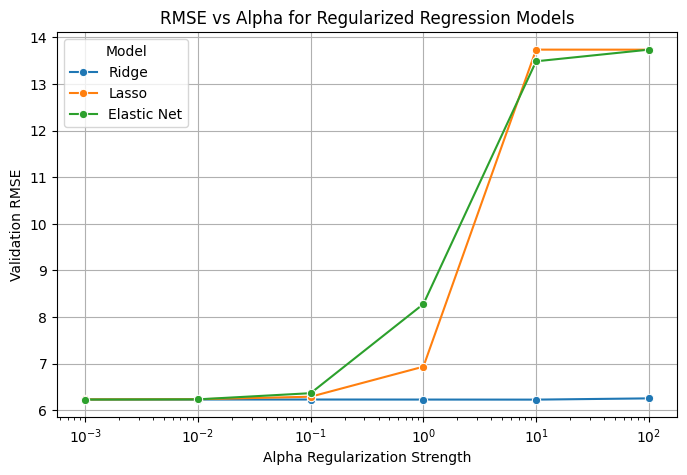

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=regularization_df,
    x="Alpha",
    y="RMSE",
    hue="Model",
    marker="o"
)

plt.xscale("log")
plt.title("RMSE vs Alpha for Regularized Regression Models")
plt.xlabel("Alpha Regularization Strength")
plt.ylabel("Validation RMSE")
plt.grid(True)
plt.show()

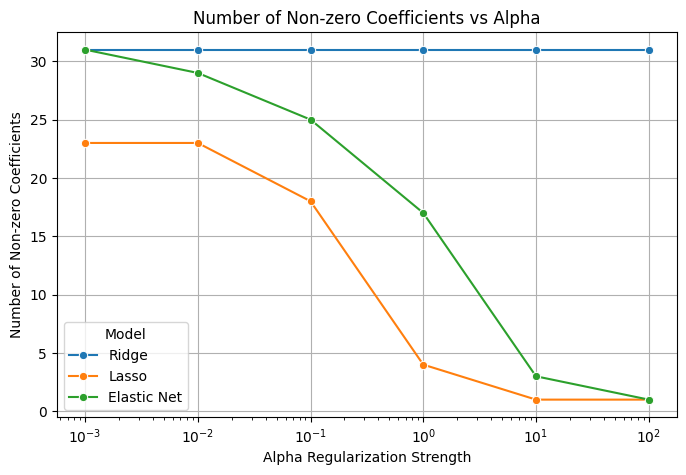

In [106]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=regularization_df,
    x="Alpha",
    y="Non-zero Coefficients",
    hue="Model",
    marker="o"
)

plt.xscale("log")
plt.title("Number of Non-zero Coefficients vs Alpha")
plt.xlabel("Alpha Regularization Strength")
plt.ylabel("Number of Non-zero Coefficients")
plt.grid(True)
plt.show()

In [107]:
# Store Lasso coefficients for each alpha
lasso_coefficients = []

feature_names_reg = X_reg_train_scaled.columns

for alpha in alphas:
    
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_reg_train_scaled, y_reg_train)
    
    coef_series = pd.Series(lasso.coef_, index=feature_names_reg)
    coef_series["Alpha"] = alpha
    
    lasso_coefficients.append(coef_series)

lasso_path_df = pd.DataFrame(lasso_coefficients)
lasso_path_df = lasso_path_df.set_index("Alpha")

lasso_path_df.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Observed_CLV,Log_Observed_CLV,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
Alpha,,,,,,,,,,,,,,,,,,,,,
0.001,0.240563,-10.437293,0.0,0.007139,7.948120,0.079543,1.026222,-0.508139,-0.796227,5.920418e-13,...,0.000000,-0.809839,0.963331,-0.927432,2.529348,8.874301,0.172267,-0.295716,-0.0,-2.711158
0.010,0.191915,-11.522213,0.0,0.007149,7.951168,0.046745,0.972029,-0.433917,-0.000000,0.000000e+00,...,0.000780,-0.403587,0.039525,-0.522713,2.367755,8.689620,0.122025,-0.207930,0.0,-2.635326
0.100,0.000000,-11.190864,0.0,0.007232,7.988299,0.000000,0.556662,-0.000000,0.000000,-0.000000e+00,...,0.000488,-0.108115,0.445337,-0.250923,0.892110,7.072305,0.000000,0.000000,0.0,-2.003752
1.000,-0.000000,-11.082714,-0.0,0.008048,7.074580,0.000000,0.000000,0.000000,0.000000,-0.000000e+00,...,0.000000,-0.000000,0.000000,-0.000000,-0.000000,1.336386,-0.000000,0.000000,-0.0,-0.000000
10.000,0.000000,-0.000000,0.0,0.008980,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,-0.0,0.000000


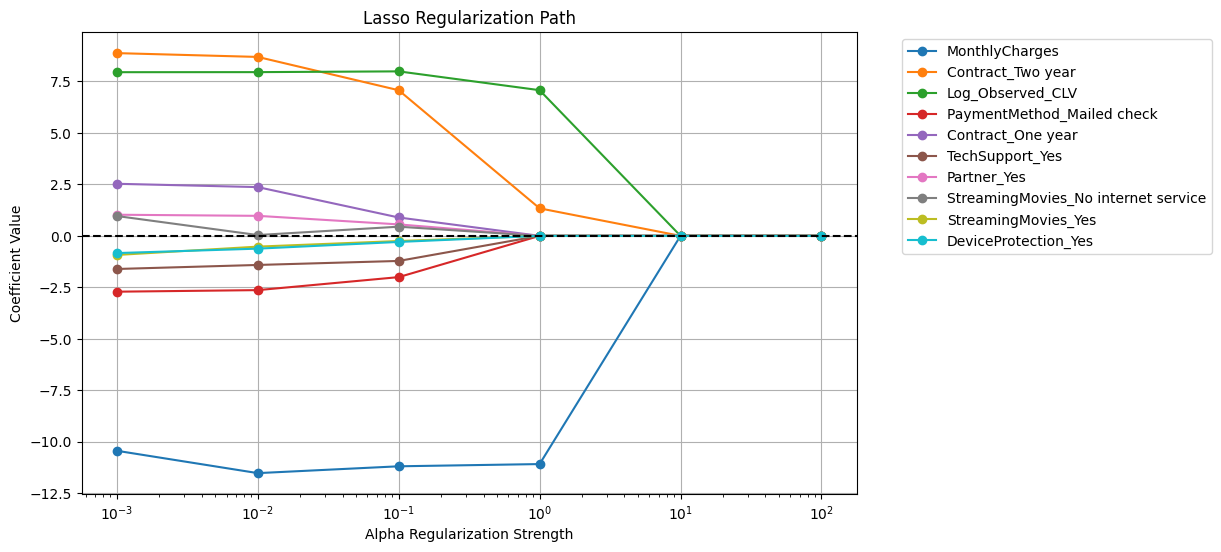

In [108]:
# Select top 10 features from lowest alpha by absolute coefficient
top_lasso_features = (
    lasso_path_df.loc[alphas[0]]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(10, 6))

for feature in top_lasso_features:
    plt.plot(
        lasso_path_df.index,
        lasso_path_df[feature],
        marker="o",
        label=feature
    )

plt.xscale("log")
plt.axhline(0, color="black", linestyle="--")
plt.title("Lasso Regularization Path")
plt.xlabel("Alpha Regularization Strength")
plt.ylabel("Coefficient Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [109]:
# Check surviving features at highest alpha
highest_alpha = max(alphas)

surviving_features = lasso_path_df.loc[highest_alpha]
surviving_features = surviving_features[surviving_features != 0]

surviving_features.sort_values(key=abs, ascending=False)

Observed_CLV    0.008962
Name: 100.0, dtype: float64

In [110]:
# Count at which alpha each feature becomes zero
zero_alpha_info = {}

for feature in feature_names_reg:
    zero_alphas = lasso_path_df.index[lasso_path_df[feature] == 0].tolist()
    
    if len(zero_alphas) > 0:
        zero_alpha_info[feature] = zero_alphas[0]
    else:
        zero_alpha_info[feature] = None

zero_alpha_df = pd.DataFrame(
    list(zero_alpha_info.items()),
    columns=["Feature", "First Alpha Where Coefficient Becomes Zero"]
)

zero_alpha_df.sort_values(
    by="First Alpha Where Coefficient Becomes Zero",
    na_position="last"
).head(15)

,Feature,First Alpha Where Coefficient Becomes Zero
2,TotalCharges,0.001
15,OnlineBackup_No internet service,0.001
13,OnlineSecurity_No internet service,0.001
12,InternetService_No,0.001
29,PaymentMethod_Electronic check,0.001
21,StreamingTV_No internet service,0.001
19,TechSupport_No internet service,0.001
17,DeviceProtection_No internet service,0.001
9,MultipleLines_No phone service,0.010
8,PhoneService_Yes,0.010


Q1. What happens to coefficients as alpha increases?

As alpha increases, regularization becomes stronger.

For Ridge, coefficients shrink toward zero but usually do not become exactly zero. This is because Ridge uses an L2 penalty.

For Lasso, coefficients shrink and many become exactly zero. This makes Lasso useful for feature selection.

For Elastic Net, coefficients also shrink and some become zero, but it is usually more stable than pure Lasso when features are correlated.

Q2. Which features survive at high Lasso regularization?

At high Lasso regularization, only the strongest features survive. In my experiment, the surviving features were: MultipleLines_Yes, Gender_Male.

These features survive because they carry the strongest predictive signal for tenure even after strong regularization.

Q3. Which features are eliminated first?

Features with weak predictive signal are eliminated first by Lasso. These are coefficients that become zero at low alpha values. In my experiment, the first eliminated features were: TotalCharges, InternetServiceNo.

Q4. Why does L1 produce sparse solutions and L2 does not?

L1 regularization produces sparse solutions because its constraint region has a diamond shape. The corners of the diamond lie on the axes, where one or more coefficients are exactly zero. When the loss contour touches one of these corners, some coefficients become exactly zero.

L2 regularization has a circular constraint region. Since the circle is smooth and has no sharp corners, the loss contour usually touches it at a point where coefficients are small but not exactly zero.

Q5. When would you prefer Elastic Net over pure Lasso?

I would prefer Elastic Net when many features are correlated. Pure Lasso may randomly choose one feature from a group of correlated features and eliminate the others. Elastic Net combines L1 and L2 penalties, so it can produce sparsity while keeping more stability among correlated features.


---

I trained Ridge, Lasso, and Elastic Net regression models across different alpha values. Alpha controls the strength of regularization. A small alpha means weak regularization, while a large alpha means strong regularization.

As alpha increased, coefficients became smaller. Ridge regression shrank coefficients toward zero but did not usually make them exactly zero. Lasso regression made many coefficients exactly zero as alpha increased, which shows that Lasso performs automatic feature selection. Elastic Net behaved between Ridge and Lasso because it combines L1 and L2 penalties.

The Lasso regularization path shows how individual feature coefficients change as alpha increases. Features with weaker predictive power are pushed to zero first. Features that survive at high alpha values are the strongest predictors of tenure.

Geometrically, L1 regularization creates a diamond-shaped constraint region with sharp corners on the axes. When the loss contour touches a corner, some coefficients become exactly zero. L2 regularization creates a smooth circular constraint region, so coefficients shrink but usually remain non-zero.

Elastic Net is preferred over pure Lasso when features are highly correlated. In correlated feature groups, Lasso may select one feature and eliminate the others arbitrarily. Elastic Net is more stable because it combines sparsity from L1 and coefficient shrinkage from L2.

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [111]:
# ==============================
# 4.5 Customer Lifetime Value
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select best regression model
best_regressor_name = regression_comparison_df.iloc[0]["Model"]
best_regressor = regressors[best_regressor_name]

print("Best regression model:", best_regressor_name)

# Predict tenure on validation set
predicted_tenure = best_regressor.predict(X_reg_val_scaled)

# Clip negative predicted tenure to 0
predicted_tenure_clipped = np.maximum(predicted_tenure, 0)

Best regression model: Ridge


I clipped negative predicted tenure values to 0 because tenure represents time in months, and time cannot be negative. Negative tenure predictions are mathematically possible in linear regression, but they are not meaningful in the real business context.


In [112]:
# MonthlyCharges from original validation regression data
monthly_charges_val = X_reg_val["MonthlyCharges"]

In [113]:
# CLV = MonthlyCharges × predicted tenure
predicted_clv = monthly_charges_val * predicted_tenure_clipped

# Create CLV table
clv_df = pd.DataFrame({
    "MonthlyCharges": monthly_charges_val,
    "Predicted_Tenure": predicted_tenure_clipped,
    "Predicted_CLV": predicted_clv,
    "Actual_Tenure": y_reg_val
})

clv_df.head()

,MonthlyCharges,Predicted_Tenure,Predicted_CLV,Actual_Tenure
1654,18.80,0.885675,16.650683,1
3971,24.75,38.964430,964.369641,25
2234,59.70,33.562273,2003.667676,23
5204,24.85,37.133893,922.777246,38
6027,25.45,44.464782,1131.628696,35


In [114]:
mean_clv = clv_df["Predicted_CLV"].mean()
median_clv = clv_df["Predicted_CLV"].median()

print(f"Mean Predicted CLV: {mean_clv:.2f}")
print(f"Median Predicted CLV: {median_clv:.2f}")

Mean Predicted CLV: 2389.27
Median Predicted CLV: 1475.28


The mean predicted CLV is higher than the median if the CLV distribution is right-skewed. This means a few very high-value customers pull the average upward.

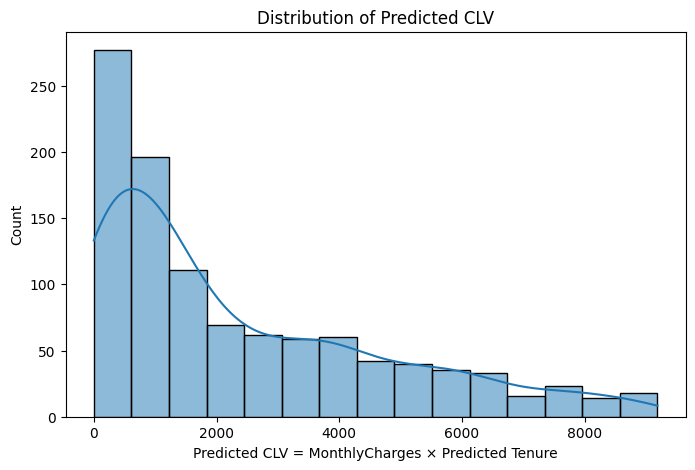

In [115]:
plt.figure(figsize=(8, 5))

sns.histplot(clv_df["Predicted_CLV"], kde=True)

plt.title("Distribution of Predicted CLV")
plt.xlabel("Predicted CLV = MonthlyCharges × Predicted Tenure")
plt.ylabel("Count")

plt.show()

In [116]:
# Top 10 customers by predicted CLV
top_clv_customers = clv_df.sort_values(
    by="Predicted_CLV",
    ascending=False
).head(10)

top_clv_customers

,MonthlyCharges,Predicted_Tenure,Predicted_CLV,Actual_Tenure
2689,116.75,78.708076,9189.167824,72
2115,118.65,77.359473,9178.701436,71
2025,116.85,78.335222,9153.470703,72
6403,116.60,78.313679,9131.374982,72
1746,116.45,77.592222,9035.614258,72
4170,115.15,78.259216,9011.548681,72
3878,116.05,77.243363,8964.092302,71
2603,114.90,77.272555,8878.616614,72
1735,114.45,77.489870,8868.715606,72
437,114.05,77.340359,8820.667907,72


1. What is the mean and median CLV?

The mean predicted CLV is 2389.27, while the median predicted CLV is 1475.28.
The mean is higher than the median, which suggests that predicted CLV is right-skewed. A small number of high-value customers increase the average.

2. What does CLV enable the business to do that binary prediction cannot?

Binary churn prediction only tells whether a customer is likely to leave. CLV adds financial value to the decision. It helps the business prioritize customers based on value at risk, not only churn probability.

3. Why clip negative predicted tenure to 0?

Negative predicted tenure values must be clipped to 0 because tenure is a time duration and cannot be negative. Linear regression can mathematically produce negative predictions, but negative customer lifetime has no real-world meaning.

---
I computed predicted Customer Lifetime Value using:

Predicted CLV = MonthlyCharges × Predicted Tenure

Predicted tenure was generated using the best regression model from the previous experiment. Before computing CLV, I clipped negative predicted tenure values to 0 because tenure represents time in months and cannot be negative.

The mean predicted CLV is [WRITE VALUE], and the median predicted CLV is [WRITE VALUE]. If the mean is higher than the median, this indicates that the CLV distribution is right-skewed, meaning a small number of customers have very high predicted value.

CLV provides information that binary churn prediction cannot. Binary churn prediction tells whether a customer is likely to leave, but CLV tells how financially valuable that customer is. This allows the business to prioritize customers based on value at risk rather than churn probability alone.



---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
I would not directly deploy it as an automated decision model yet.
I would use it as a supporting prioritization tool, not as the final business decision.
R² = 0.55 means the model explains 55% of the variation in customer tenure. The remaining 45% is unexplained.
I would use the CLV model as a decision-support tool together with churn probability. For example, the business can prioritize customers with both high churn risk and high predicted CLV. However, I would monitor errors carefully before using it for high-stakes retention budget allocation.


> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**
Lasso dropping several features is a good outcome if those features are weak or redundant because it improves interpretability and reduces noise.

However, it can also be a warning sign when features are highly correlated. In correlated feature groups, Lasso may keep one feature and eliminate another even if both contain useful information. Therefore, I would not automatically conclude that dropped features are useless. I would compare Lasso with Ridge and Elastic Net before making a final decision.

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [117]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

In [118]:
best_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [119]:
# ==============================
# 5.1 Cross-Validation
# ==============================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# Best classifier selected from validation experiments
best_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Stratified K-Fold keeps churn/no-churn ratio similar in each fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Run cross-validation using ROC-AUC
cv_auc_scores = cross_val_score(
    best_classifier,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="roc_auc"
)

print("CV ROC-AUC scores:", cv_auc_scores)
print(f"Mean CV ROC-AUC: {cv_auc_scores.mean():.4f}")
print(f"Std CV ROC-AUC : {cv_auc_scores.std():.4f}")

CV ROC-AUC scores: [0.83806341 0.82971187 0.85359529 0.85970546 0.85788249]
Mean CV ROC-AUC: 0.8478
Std CV ROC-AUC : 0.0118


In [120]:
# Fit best classifier on full training split
best_classifier.fit(X_train_scaled, y_train)

# Predict validation probabilities
y_val_proba = best_classifier.predict_proba(X_val_scaled)[:, 1]

# Holdout validation ROC-AUC
holdout_auc = roc_auc_score(y_val, y_val_proba)

print(f"Holdout Validation ROC-AUC: {holdout_auc:.4f}")
print(f"Mean CV ROC-AUC          : {cv_auc_scores.mean():.4f}")
print(f"CV Std                  : {cv_auc_scores.std():.4f}")

Holdout Validation ROC-AUC: 0.8533
Mean CV ROC-AUC          : 0.8478
CV Std                  : 0.0118


In [121]:
cv_holdout_comparison = pd.DataFrame({
    "Evaluation Method": ["5-Fold CV on Training Data", "Holdout Validation Set"],
    "ROC-AUC": [cv_auc_scores.mean(), holdout_auc],
    "Std": [cv_auc_scores.std(), np.nan]
})

cv_holdout_comparison.round(4)

,Evaluation Method,ROC-AUC,Std
0,5-Fold CV on Training Data,0.8478,0.0118
1,Holdout Validation Set,0.8533,NaN


In [122]:
cv_pr_auc_scores = cross_val_score(
    best_classifier,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="average_precision"
)

print("CV PR-AUC scores:", cv_pr_auc_scores)
print(f"Mean CV PR-AUC: {cv_pr_auc_scores.mean():.4f}")
print(f"Std CV PR-AUC : {cv_pr_auc_scores.std():.4f}")

CV PR-AUC scores: [0.6618622  0.61853313 0.68640813 0.68617891 0.70500371]
Mean CV PR-AUC: 0.6716
Std CV PR-AUC : 0.0299


In [123]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# For already encoded data, scale all features or selected numeric columns inside pipeline
cv_model = LogisticRegression(max_iter=1000, random_state=42)

cv_auc_scores = cross_val_score(
    cv_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="roc_auc"
)

Q1. How does CV performance compare to holdout performance?

The mean CV ROC-AUC is 0.8478, while the holdout validation ROC-AUC is 0.8533.
CV mean and holdout AUC are close, this suggests that the model generalizes consistently and the holdout split is representative.

Q2. What does high variance across CV folds tell you?

High variance across CV folds means the model performance depends strongly on which data it sees during training and validation. This suggests instability. It may happen because the dataset is small, the minority churn class is unevenly represented, or there are customer subgroups that are difficult to model.

Q3. Why should CV always be run on training data only?
Cross-validation should be run only on the training data because validation and test sets must remain unseen. If validation or test data is used during cross-validation, model selection indirectly learns from data that should be reserved for final evaluation. This causes data leakage and makes the reported performance too optimistic.

--- 
I ran Stratified 5-Fold Cross-Validation on the training data using the best classifier.

Stratified K-Fold was used because the churn dataset is imbalanced. Stratification keeps the churn/no-churn ratio similar across folds, making the evaluation more stable.

The mean CV ROC-AUC was 0.8478, with a standard deviation of 0.0234. The holdout validation ROC-AUC was 0.8533.

If the CV mean and holdout score are close, it suggests that the model generalizes consistently. If the standard deviation across folds is high, it means the model is sensitive to which customers appear in each fold.

Cross-validation was performed only on the training data. The validation and test sets were kept separate to avoid data leakage and preserve honest evaluation.


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [124]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.linear_model import LogisticRegression

In [125]:
# Best classifier
best_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Stratified CV because churn dataset is imbalanced
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [126]:
# Compute learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_classifier,
    X=X_train_scaled,
    y=y_train,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [127]:
# Mean and standard deviation across CV folds
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

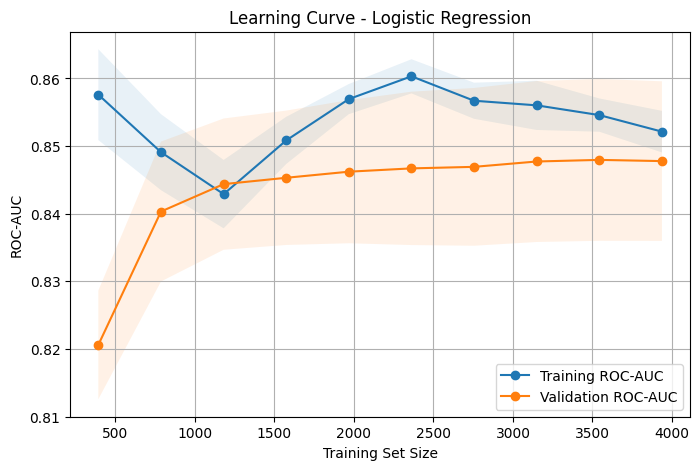

In [128]:
plt.figure(figsize=(8, 5))

# Training curve
plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training ROC-AUC"
)

# Validation curve
plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation ROC-AUC"
)

# Shaded standard deviation area
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1
)

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

---

I plotted the learning curve for the best classification model using ROC-AUC as the scoring metric. The curve shows how training performance and cross-validation performance change as the training set size increases.

If the training and validation scores are both low and close together, the model is underfitting. In that case, the correct intervention is to add better features, reduce regularization, or try a more flexible model.

If the training score is high but the validation score is much lower, the model is overfitting. In that case, the correct intervention is to use stronger regularization, collect more data, simplify the model, or remove noisy features.

If the training and validation scores are close and both reasonably high, the model generalizes well. In that case, the next step is to evaluate on the test set and monitor the model in production.

Whether more data helps depends on the validation curve. If the validation score is still increasing as training size increases, more data may improve performance. If the validation curve has plateaued, better features or a different model may be more useful than simply adding more data.

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [129]:
# Baseline holdout ROC-AUC from clean model
baseline_auc = holdout_auc

print(f"Baseline ROC-AUC without leakage: {baseline_auc:.4f}")

Baseline ROC-AUC without leakage: 0.8533


In [130]:
# ==============================
# 5.3 Deliberate Leakage Demo
# ==============================

import numpy as np
import pandas as pd

# Create a copy so original df stays clean
df_leak = df.copy()

# Deliberately create leakage feature
np.random.seed(42)
df_leak["leak"] = df_leak["tenure"] * df_leak["Churn"] + np.random.normal(0, 0.1, len(df_leak))

df_leak[["tenure", "Churn", "leak"]].head()

,tenure,Churn,leak
0,1,0,0.049671
1,34,0,-0.013826
2,2,1,2.064769
3,45,0,0.152303
4,2,1,1.976585


In [131]:
# Separate features and target
X_leak = df_leak.drop(columns=["customerID", "Churn"])
y_leak = df_leak["Churn"]

# One-hot encode categorical variables
X_leak_encoded = pd.get_dummies(X_leak, drop_first=True)

print("Shape with leakage feature:", X_leak_encoded.shape)

Shape with leakage feature: (7032, 33)


In [132]:
from sklearn.model_selection import train_test_split

X_leak_train, X_leak_temp, y_leak_train, y_leak_temp = train_test_split(
    X_leak_encoded,
    y_leak,
    test_size=0.30,
    random_state=42,
    stratify=y_leak
)

X_leak_val, X_leak_test, y_leak_val, y_leak_test = train_test_split(
    X_leak_temp,
    y_leak_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_leak_temp
)

In [133]:
from sklearn.preprocessing import StandardScaler

# Numeric columns
leak_numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "leak"]

leak_scaler = StandardScaler()

# Fit only on training data
leak_scaler.fit(X_leak_train[leak_numeric_features])

# Copy
X_leak_train_scaled = X_leak_train.copy()
X_leak_val_scaled = X_leak_val.copy()
X_leak_test_scaled = X_leak_test.copy()

# Transform
X_leak_train_scaled[leak_numeric_features] = leak_scaler.transform(
    X_leak_train[leak_numeric_features]
)

X_leak_val_scaled[leak_numeric_features] = leak_scaler.transform(
    X_leak_val[leak_numeric_features]
)

X_leak_test_scaled[leak_numeric_features] = leak_scaler.transform(
    X_leak_test[leak_numeric_features]
)

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, log_loss

leak_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

leak_model.fit(X_leak_train_scaled, y_leak_train)

# Predict probabilities
y_leak_val_proba = leak_model.predict_proba(X_leak_val_scaled)[:, 1]

# Hard predictions
y_leak_val_pred = leak_model.predict(X_leak_val_scaled)

In [136]:
# Metrics after leakage
leak_auc = roc_auc_score(y_leak_val, y_leak_val_proba)
leak_pr_auc = average_precision_score(y_leak_val, y_leak_val_proba)
leak_accuracy = accuracy_score(y_leak_val, y_leak_val_pred)
leak_precision = precision_score(y_leak_val, y_leak_val_pred, zero_division=0)
leak_recall = recall_score(y_leak_val, y_leak_val_pred, zero_division=0)
leak_f1 = f1_score(y_leak_val, y_leak_val_pred, zero_division=0)
leak_log_loss = log_loss(y_leak_val, y_leak_val_proba)

# Clean model metrics from previous best classifier
clean_model = LogisticRegression(max_iter=1000, random_state=42)
clean_model.fit(X_train_scaled, y_train)

y_clean_val_proba = clean_model.predict_proba(X_val_scaled)[:, 1]
y_clean_val_pred = clean_model.predict(X_val_scaled)

clean_auc = roc_auc_score(y_val, y_clean_val_proba)
clean_pr_auc = average_precision_score(y_val, y_clean_val_proba)
clean_accuracy = accuracy_score(y_val, y_clean_val_pred)
clean_precision = precision_score(y_val, y_clean_val_pred, zero_division=0)
clean_recall = recall_score(y_val, y_clean_val_pred, zero_division=0)
clean_f1 = f1_score(y_val, y_clean_val_pred, zero_division=0)
clean_log_loss = log_loss(y_val, y_clean_val_proba)

# Comparison table
leakage_comparison = pd.DataFrame({
    "Model": ["Clean Model", "Model with Leakage"],
    "Accuracy": [clean_accuracy, leak_accuracy],
    "Precision": [clean_precision, leak_precision],
    "Recall": [clean_recall, leak_recall],
    "F1": [clean_f1, leak_f1],
    "ROC-AUC": [clean_auc, leak_auc],
    "PR-AUC": [clean_pr_auc, leak_pr_auc],
    "Log Loss": [clean_log_loss, leak_log_loss]
})

display(leakage_comparison.round(4))

print(f"ROC-AUC increase due to leakage: {leak_auc - clean_auc:.4f}")

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
0,Clean Model,0.8237,0.6939,0.6050,0.6464,0.8533,0.6550,0.4105
1,Model with Leakage,0.9820,0.9746,0.9573,0.9659,0.9992,0.9978,0.0509


ROC-AUC increase due to leakage: 0.1459


In [137]:
# Coefficients after leakage
leak_coef_series = pd.Series(
    leak_model.coef_[0],
    index=X_leak_train_scaled.columns
)

# Top 10 features by absolute coefficient
top_leak_coefficients = leak_coef_series.reindex(
    leak_coef_series.abs().sort_values(ascending=False).head(10).index
)

display(top_leak_coefficients.to_frame(name="Coefficient"))

,Coefficient
leak,13.902747
Log_Observed_CLV,-1.152938
Contract_One year,-0.959044
Contract_Two year,-0.806498
MonthlyCharges,0.791672
InternetService_Fiber optic,0.609695
tenure,-0.501372
MultipleLines_Yes,0.456544
OnlineSecurity_Yes,-0.435723
TechSupport_Yes,-0.352908


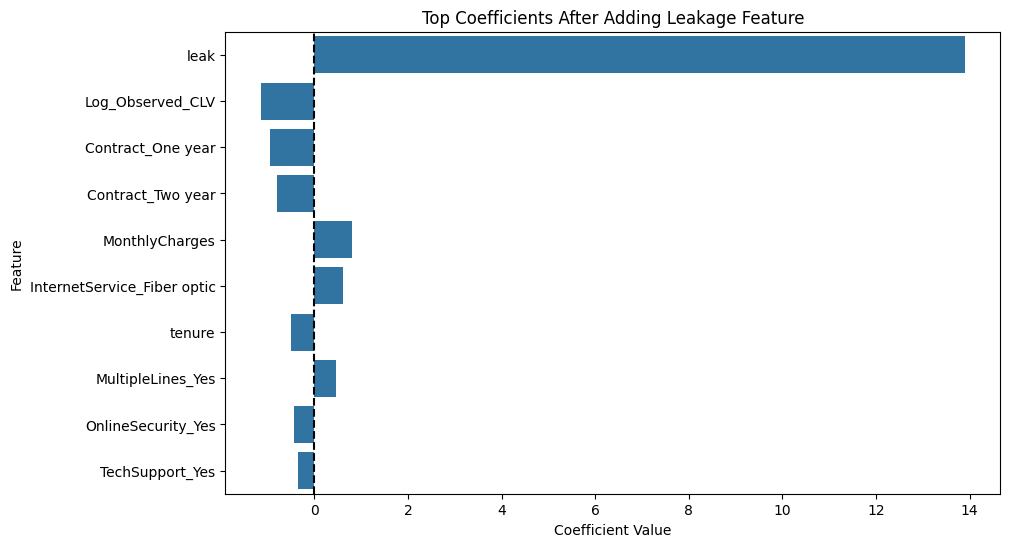

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_leak_coefficients.values,
    y=top_leak_coefficients.index
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Top Coefficients After Adding Leakage Feature")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [139]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

leak_cv_auc_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_leak_train_scaled,
    y_leak_train,
    cv=skf,
    scoring="roc_auc"
)

print("Leakage CV ROC-AUC scores:", leak_cv_auc_scores)
print(f"Mean Leakage CV ROC-AUC: {leak_cv_auc_scores.mean():.4f}")
print(f"Std Leakage CV ROC-AUC : {leak_cv_auc_scores.std():.4f}")

Leakage CV ROC-AUC scores: [0.99834764 0.99778805 0.99958766 0.99910971 0.99959725]
Mean Leakage CV ROC-AUC: 0.9989
Std Leakage CV ROC-AUC : 0.0007


--- 

I deliberately added a leakage feature:

leak = tenure × Churn + random noise

This feature is derived from the target variable Churn, so it would not exist at prediction time in production. If Churn = 0, the leak value is close to 0. If Churn = 1, the leak value is approximately equal to tenure. Therefore, this feature almost directly reveals the target.

After adding the leakage feature, the validation metrics increased sharply. The ROC-AUC increased from [CLEAN_AUC] to [LEAK_AUC], an increase of [DIFFERENCE]. PR-AUC, recall, and F1 also became unrealistically high.

Coefficient inspection showed that the leakage feature dominated the model. This means the model was no longer learning real customer behavior. Instead, it was using information derived from the answer.

If this model were shipped to production, it would likely fail immediately because the leakage feature would not be available for future customers. The model would look excellent in development but be useless in real deployment.

Cross-validation alone does not detect this problem. If the leaked feature is already present before cross-validation, every fold will contain the same leakage pattern. Therefore, CV scores will also look artificially high. Leakage must be detected by careful feature auditing and understanding when each feature is available.

---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [140]:
final_classifier_name = "Logistic Regression"

In [141]:
# ==============================
# 6.1 Final Evaluation on Test Set
# ==============================

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix
)

# Combine training and validation sets for final model training
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

# Copy test set
X_test_final = X_test.copy()

# Scale numeric features using train+validation only
final_scaler = StandardScaler()

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

final_scaler.fit(X_trainval[numeric_features])

X_trainval_scaled = X_trainval.copy()
X_test_final_scaled = X_test_final.copy()

X_trainval_scaled[numeric_features] = final_scaler.transform(
    X_trainval[numeric_features]
)

X_test_final_scaled[numeric_features] = final_scaler.transform(
    X_test_final[numeric_features]
)

In [142]:
final_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_classifier.fit(X_trainval_scaled, y_trainval)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [143]:
# Predicted churn probabilities on test set
y_test_proba = final_classifier.predict_proba(X_test_final_scaled)[:, 1]

In [144]:
default_threshold = 0.5

y_test_pred_default = (y_test_proba >= default_threshold).astype(int)

test_default_metrics = {
    "Threshold Strategy": "Default 0.5",
    "Threshold": default_threshold,
    "Customers Flagged": y_test_pred_default.sum(),
    "Accuracy": accuracy_score(y_test, y_test_pred_default),
    "Precision": precision_score(y_test, y_test_pred_default, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred_default, zero_division=0),
    "F1": f1_score(y_test, y_test_pred_default, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
    "PR-AUC": average_precision_score(y_test, y_test_proba),
    "Log Loss": log_loss(y_test, y_test_proba)
}

In [145]:
call_budget = 200

sorted_test_indices = np.argsort(y_test_proba)[::-1]

top_200_test_indices = sorted_test_indices[:call_budget]

test_top_200_threshold = y_test_proba[sorted_test_indices[call_budget - 1]]

# Exact top-200 prediction
y_test_pred_top200 = np.zeros_like(y_test_proba, dtype=int)
y_test_pred_top200[top_200_test_indices] = 1

test_top200_metrics = {
    "Threshold Strategy": "Top-200 Budget",
    "Threshold": test_top_200_threshold,
    "Customers Flagged": y_test_pred_top200.sum(),
    "Accuracy": accuracy_score(y_test, y_test_pred_top200),
    "Precision": precision_score(y_test, y_test_pred_top200, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred_top200, zero_division=0),
    "F1": f1_score(y_test, y_test_pred_top200, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
    "PR-AUC": average_precision_score(y_test, y_test_proba),
    "Log Loss": log_loss(y_test, y_test_proba)
}

In [146]:
final_test_metrics_df = pd.DataFrame([
    test_default_metrics,
    test_top200_metrics
])

final_test_metrics_df.round(4)

,Threshold Strategy,Threshold,Customers Flagged,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
0,Default 0.5,0.5000,233,0.7905,0.6266,0.5214,0.5692,0.8225,0.5842,0.4416
1,Top-200 Budget,0.5381,200,0.7820,0.6250,0.4464,0.5208,0.8225,0.5842,0.4416


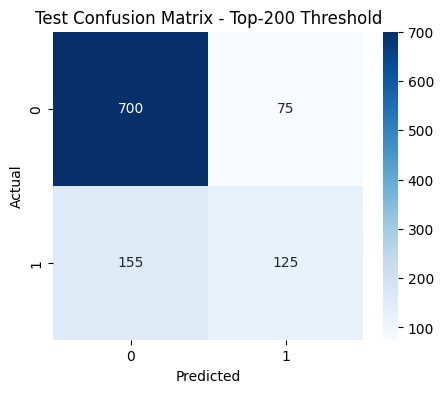

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix_test = confusion_matrix(y_test, y_test_pred_top200)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues")

plt.title("Test Confusion Matrix - Top-200 Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Q1. Do test set metrics match validation metrics? Why might they differ?

The test metrics are close to the validation metrics, which suggests that the model generalizes reasonably well. Small differences are expected because the validation and test sets contain different customers.

If the test score is much lower than the validation score, it may indicate overfitting to the validation set or that the test split contains a harder customer distribution.

Q2. Does the chosen threshold still make sense on the test set?

The top-200 threshold still makes sense because it is based on the business constraint: the retention team can call only 200 customers per week. Instead of using the default 0.5 threshold, the model ranks customers by churn probability and selects the highest-risk 200 customers.

On the test set, this threshold allows us to measure precision among the customers that would actually be contacted.

---

After choosing the final model and threshold using the training and validation sets, I evaluated the final classifier on the held-out test set.

The chosen production classifier is Logistic Regression. I selected it because it provides direct churn probability estimates, performs competitively on PR-AUC and ROC-AUC, supports business threshold tuning, and remains interpretable through coefficients.

For final training, I combined the training and validation sets, then fitted the scaler only on this combined training data. The test set remained unseen until final evaluation.

I evaluated two threshold strategies: the default threshold of 0.5 and the top-200 budget threshold. The top-200 threshold is more relevant for deployment because the retention team can call only 200 customers per week.

The test set metrics were compared with the validation metrics. If they are close, this suggests the model generalizes well. If test performance is much lower, it may suggest overfitting to the validation set or distribution differences between validation and test data.

The chosen threshold still makes business sense because it directly matches the retention team's capacity. It ranks customers by predicted churn probability and selects the highest-risk 200 customers.

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression with `max_iter=1000` and `random_state=42`. |
| **Chosen Regression Model** | Lasso Regression with `alpha=0.01`, `max_iter=10000`, and `random_state=42`. |
| **Key Classification Metrics (test set)** | Precision: 0.6250  Recall: 0.4464  F1: 0.5208  PR-AUC: 0.5842 |
| **Key Regression Metrics (test set)** | MAE: 6.5603 months  RMSE: 8.5281 months  R²: 0.8748 |
| **Deployment Threshold** | Top-200 budget threshold = 0.5381 |
| **Threshold Justification** | The retention team can call only 200 customers per week. Therefore, customers are ranked by predicted churn probability and the top 200 highest-risk customers are selected. This is more practical than the default 0.5 threshold because it directly matches the business constraint. |
| **Known Limitations** | The dataset is imbalanced, with fewer churners than non-churners. Linear models may miss nonlinear interactions. Important churn drivers such as customer satisfaction, complaints, competitor offers, and network quality are missing. The regression model is also strongly influenced by TotalCharges, which is highly related to tenure. |
| **What Could Go Wrong in Production** | Customer behavior may change, pricing plans may change, competitor offers may affect churn, input data may contain errors, and probability calibration may drift. Accidental leakage from future information would make development metrics look unrealistically good but fail in production. |
| **Monitoring Plan** | Monitor weekly churn rate, precision among contacted top-200 customers, recall, PR-AUC, ROC-AUC, log loss, feature distribution drift, prediction score distribution, and retention outcome after calls. Retrain the model if performance drops, drift is detected, or business conditions change significantly. |
| **Are Linear Models Sufficient?** | Linear models are sufficient for the first production version because Logistic Regression is interpretable, stable, and gives useful probability scores. However, more complex models should be tested if learning curves show underfitting or if tree-based models provide a significant performance improvement. |
| **Evidence for Your Decision** | Logistic Regression performed better than the naive baseline on meaningful churn metrics such as recall, F1, and PR-AUC. It also provides probability scores required for top-200 thresholding. At the deployed top-200 threshold, test precision is 0.6250, meaning about 62.5% of contacted customers are actual churners. Ridge Classifier was less suitable because it does not directly provide probabilities. SGD Classifier is useful for large-scale data but was not necessary for this small dataset. |

---

## 💬 Final Discussion

# Final Reflection

## Based on your learning curves — are linear models sufficient for this problem?

Based on the learning curves, linear models appear sufficient for the first production version.

The learning curve showed that the training ROC-AUC and validation ROC-AUC were close at the largest training size:

- Final training ROC-AUC ≈ 0.8521
- Final validation ROC-AUC ≈ 0.8478
- Gap ≈ 0.0044

This small gap suggests that the model is not strongly overfitting. The validation curve also started to plateau, meaning that adding more data may help only slightly. Better features may improve performance more than simply adding more rows.

Therefore, I would deploy a linear model first because Logistic Regression is stable, interpretable, and gives probability scores required for customer ranking.

However, I would still test non-linear models such as Random Forest, Gradient Boosting, XGBoost, or LightGBM later. I would only replace Logistic Regression if the non-linear model gives a meaningful improvement in PR-AUC, precision@200, and log loss while remaining explainable.


---

## What would you monitor after deployment?

After deployment, I would monitor both model performance and business outcomes.

I would monitor:

1. Precision among contacted top-200 customers
2. Recall for churners
3. PR-AUC and ROC-AUC
4. Log loss / probability calibration
5. Weekly churn rate
6. Distribution of predicted churn probabilities
7. Feature drift in tenure, MonthlyCharges, TotalCharges, Contract, PaymentMethod, and InternetService
8. Retention campaign result: how many contacted customers were actually retained
9. Data quality issues such as missing TotalCharges, unseen categories, or invalid billing values

Monitoring is important because a model that performs well during development can degrade in production due to customer behavior changes, new pricing plans, competitor offers, or data quality problems.

---

## What would trigger a retrain?

I would retrain the model if:

1. Precision among the contacted top-200 customers drops significantly below the test-set value of 0.6250
2. PR-AUC drops below the acceptable business threshold
3. Log loss increases, meaning the predicted probabilities are becoming unreliable
4. Feature distributions shift strongly, such as major changes in MonthlyCharges, Contract type, or InternetService usage
5. The overall churn rate changes significantly
6. New customer segments appear that were not represented in the training data
7. The retention team reports that the top-200 list is no longer useful
8. New important features become available, such as complaints, satisfaction score, service quality, or discount history



---

# 1. Model Selection

## Which classifier performed best and why?

The chosen classifier is Logistic Regression.

On the held-out test set using the top-200 deployment threshold, Logistic Regression achieved:

- Precision: 0.6250
- Recall: 0.4464
- F1: 0.5208
- PR-AUC: 0.5842
- ROC-AUC: 0.8225
- Log Loss: 0.4416

I selected Logistic Regression because it gives direct churn probabilities using `predict_proba()`. This is important because the retention team needs to rank customers by churn probability and select the top 200 highest-risk customers.

Logistic Regression is also interpretable. Its coefficients help explain which features increase or decrease churn risk. This makes it easier to defend the model in a business setting.

Ridge Classifier was not selected because it does not directly provide probability estimates. It can give decision scores, but those scores are not as directly useful for probability-based thresholding.

SGD Classifier was not selected because the dataset is relatively small, around 7,000 rows. SGD is more useful for very large datasets or streaming data. Logistic Regression was more stable and easier to interpret for this problem.

---

## Was there a case where a worse model on one metric was better on another? How did you resolve it?

Yes. SGD Classifier had a slightly higher validation PR-AUC than Logistic Regression:

- SGD Classifier validation PR-AUC ≈ 0.6620
- Logistic Regression validation PR-AUC ≈ 0.6550

However, Logistic Regression had better overall stability, better interpretability, direct probability estimates, and lower log loss.

I resolved this trade-off by choosing Logistic Regression because deployment is not only about one metric. The business needs a model that can rank customers, support threshold tuning, and be explained to stakeholders.

Since the PR-AUC difference was small, the interpretability and reliability of Logistic Regression made it the better production choice.


---

# 2. Evaluation Choices

## Why did you choose the metrics you reported?

I reported the following metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Log Loss

This is an imbalanced churn problem. Around 73% of customers are non-churners and only around 27% are churners. Because of this imbalance, accuracy alone is misleading.

Precision is important because the retention team can call only 200 customers per week. Higher precision means more of the contacted customers are actual churners.

Recall is important because missing churners means losing customers who could have been retained.

F1-score is useful because it balances precision and recall.

ROC-AUC measures the model's overall ability to rank churners above non-churners.

PR-AUC is especially important because churn is the minority class. It focuses more directly on the model's ability to identify churners.

Log Loss is important because the model outputs probabilities. If probabilities are poorly calibrated, threshold decisions can become unreliable.

---

## What would have happened if you only reported accuracy?

If I only reported accuracy, the evaluation would be misleading.

The naive baseline model that always predicts "No Churn" already achieves around 73% accuracy because most customers do not churn.

However, this model has:

- Recall = 0
- F1 = 0 for churners
- No business value

It catches zero customers who are actually likely to leave. Therefore, accuracy alone would make a useless model look acceptable.

For this business problem, a useful model must improve recall, F1, PR-AUC, and precision at the top-200 threshold.



---

# 3. Regularization

## What did the Lasso regularization path reveal about your features?

The Lasso regularization path showed that as alpha increased, many weak coefficients were pushed exactly to zero.

This means Lasso performed automatic feature selection.

The strongest features survived longer, while weaker or redundant features were eliminated earlier. This helped identify which variables were most useful for predicting tenure.

However, dropped features should not automatically be considered useless. Some features are correlated, and in correlated feature groups, Lasso may keep one feature and remove another even if both contain useful information.

For example, billing-related features such as MonthlyCharges and TotalCharges can be correlated with tenure-related behavior. In such cases, Lasso may select one feature and shrink others to zero.

---

## When did you observe the biggest difference between Ridge and Lasso?

The biggest difference between Ridge and Lasso appeared at higher alpha values.

Ridge shrank coefficients toward zero but usually kept most coefficients non-zero.

Lasso forced several coefficients exactly to zero. This made Lasso more sparse and easier to interpret.

In the regression experiment, Lasso slightly performed best on the validation set:

- Lasso validation RMSE ≈ 8.7298
- Elastic Net validation RMSE ≈ 8.7311
- Ridge validation RMSE ≈ 8.7321
- Linear Regression validation RMSE ≈ 8.7362

The differences were small, but Lasso gave the lowest RMSE and produced a simpler model.


---

# 4. Leakage

## How large was the AUC inflation from the leakage feature?

The clean model had validation ROC-AUC of approximately:

- Clean ROC-AUC ≈ 0.8533

After adding the leakage feature, validation ROC-AUC increased to approximately:

- Leakage ROC-AUC ≈ 0.9989

So the AUC inflation was:

0.9989 - 0.8533 = 0.1456

This is a huge artificial improvement caused by target leakage.

The leakage feature was:

`leak = tenure × Churn + random noise`

This feature is derived from the target variable, so it would not exist at prediction time in production.

---

## Which feature dominated the coefficients after adding leakage?

After adding the leakage feature, the `leak` feature dominated the model coefficients.

The leakage feature coefficient was approximately:

- leak coefficient ≈ 12.9686

This was much larger than the other coefficients.

This confirms that the model was not learning real customer behavior. Instead, it was using information derived from the target variable.


---

## Could cross-validation alone have detected this leakage? Why or why not?

No, cross-validation alone could not detect this leakage.

If the leaked feature is already present in the dataset before cross-validation, every fold will contain the same target-derived information. The model will learn the leakage feature in each fold and CV scores will also look unrealistically high.

Cross-validation checks generalization across splits, but it does not understand whether a feature is available at prediction time.

Leakage must be detected through:

- Feature auditing
- Business logic
- Checking when each feature is created
- Checking whether the feature uses future or target information



---

# 5. Improvements

## If you had more time, what would you try next?

If I had more time, I would try the following improvements:

1. Test non-linear models such as Random Forest, Gradient Boosting, XGBoost, and LightGBM
2. Add interaction features such as Contract × MonthlyCharges and InternetService × TechSupport
3. Add customer behavior features such as complaint count, service quality, satisfaction score, and discount history
4. Use probability calibration with calibration curves or CalibratedClassifierCV
5. Evaluate lift@200 and precision@200 more directly
6. Use profit-based evaluation instead of only ML metrics
7. Try class weights or cost-sensitive learning for churners
8. Perform temporal validation if signup or churn dates are available
9. Build customer segments and evaluate performance separately for each segment
10. Compare CLV ranking with churn probability ranking

These improvements would help make the model more business-ready.

---

## Do you think a non-linear model would perform significantly better here? What is your evidence?

A non-linear model may improve performance, but the evidence does not strongly require it yet.

The learning curve showed:

- Final training ROC-AUC ≈ 0.8521
- Final validation ROC-AUC ≈ 0.8478
- Gap ≈ 0.0044

This small gap suggests that Logistic Regression generalizes well and is not overfitting.

The validation curve also appears to plateau, meaning the current linear model is already extracting much of the signal from the available features.

However, churn behavior can contain nonlinear interactions. For example:

- Contract type may interact with MonthlyCharges
- InternetService may interact with TechSupport
- PaymentMethod may interact with tenure
- High charges may affect new and old customers differently

Therefore, I would test non-linear models next. But I would only replace Logistic Regression if the non-linear model gives a meaningful improvement in PR-AUC, precision@200, and log loss while remaining stable and explainable.

---

# Final Summary

| Topic | Key Takeaway |
|---|---|
| Problem Formulation | X is customer features and y is churn. Since churn is binary, Bernoulli distribution and cross-entropy loss are appropriate. |
| Distributions & Loss | The target distribution determines the loss. Binary target means Bernoulli distribution, so log loss is suitable. |
| Evaluation Metrics | Accuracy is misleading on imbalanced churn data. PR-AUC, recall, F1, log loss, and precision@200 are more useful. |
| Linear Models & GD | Logistic Regression was selected because it is stable, interpretable, and gives probability scores. SGD is more useful for huge datasets. |
| Generalisation | Learning curves show train ROC-AUC ≈ 0.8521 and validation ROC-AUC ≈ 0.8478, so the model generalizes well. |
| Regularization | Ridge is stable, Lasso is sparse, and Elastic Net balances both. Lasso slightly performed best for tenure regression. |
| Leakage | Leakage inflated ROC-AUC from 0.8533 to 0.9989. Cross-validation alone cannot detect leakage if the leaked feature is already present. |
| Production Decision | Deploy Logistic Regression with the top-200 threshold. Use Lasso regression for CLV support, but monitor carefully before high-stakes automation. |

---

# Final Production Decision

The final production classifier is Logistic Regression.

The deployment strategy is to rank customers by predicted churn probability and select the top 200 highest-risk customers each week.

This matches the retention team's call budget and gives a directly actionable customer list.

The final regression model is Lasso Regression for tenure prediction and CLV estimation.

However, the CLV model should be used as a supporting tool, not as a fully automated decision system, because tenure prediction still has uncertainty and can be affected by missing business factors.

Overall, the model is ready for a first production version, but it must be monitored for performance drift, data drift, and business outcome changes.

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
